# Notebook 145 — Regional seismic and infrasound detectability

This notebook performs a reproducible, station-by-station search for regional signals from the 1 September 2016 Falcon 9 AMOS-6 failure. The principal explosion is the default timing reference because it was the strongest event and hence the most likely source of a regional signal.

It addresses two distinct questions:

1. Was any regional **infrasound** signal detectable at IU.DWPF or at other EarthScope microbarometer stations operating during the 2016 event?
2. Was any regional **seismic** signal detectable at IU.DWPF or other permanent stations operating near Florida? Seismic discovery prefers HHZ, then BHZ, and finally LHZ when higher-rate channels cannot be retrieved.

The notebook discovers stations that were operating in 2016, downloads waveforms and response metadata through FDSN services, removes instrument response, applies fixed screening bands, evaluates physically defined arrival windows, compares event-window amplitudes with adjacent control data, and writes a complete audit table.

Automated thresholds identify **candidates for manual review**, not confirmed detections. A manuscript statement of detection or non-detection should be made only after completing the exported review table. Stations are discovered from metadata valid at the 2016 event time; the analysis does not attempt to reproduce the different network operating during the 2026 New Glenn event.


In [1]:
from __future__ import annotations

import json
import math
import sys
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
from obspy import Inventory, Stream, Trace, UTCDateTime, read_inventory
from obspy.clients.fdsn import Client
from obspy.geodetics import gps2dist_azimuth, kilometers2degrees
from scipy.signal import hilbert, periodogram

# Locate the repository whether Jupyter starts in the project root or notebooks/.
_here = Path.cwd().resolve()
for _candidate in (_here, *_here.parents):
    if (_candidate / "modules" / "project_config.py").exists():
        PROJECT_ROOT = _candidate
        break
else:
    raise FileNotFoundError("Could not locate modules/project_config.py")

MODULE_DIR = PROJECT_ROOT / "modules"
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

import project_config as config

OUTPUT_ROOT = config.NB145_DIR
CACHE_DIR = OUTPUT_ROOT / "waveform_cache"
RESPONSE_CACHE_DIR = OUTPUT_ROOT / "response_cache"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)
RESPONSE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Output root:", OUTPUT_ROOT)


Project root: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0
Output root: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/145_analyze_regional_detectability


## Configuration

The acoustic screening band and SNR threshold follow the New Glenn regional-infrasound analysis where possible: 0.2–1.0 Hz and SNR ≥ 2.5. For low-sample-rate channels the upper filter corner is reduced automatically and the effective band is recorded. The additional event-to-control peak ratio prevents an isolated high SNR from being accepted when comparable transients occur outside the predicted arrival window.

Phase windows are deliberately broad. They are screening intervals, not atmospheric ray-tracing predictions. Each phase window is compared with pre- and post-event controls of the same duration, avoiding the bias that results when maxima from unequal-duration windows are compared. Seismic and ground-coupled-airwave windows are evaluated separately. The principal explosion is used as the reference source because it was the strongest event and is the most likely regional source.


In [2]:
FDSN_PROVIDER = "EARTHSCOPE"
REFERENCE_EVENT_KEY = "lower_stage"
REFERENCE_EVENT_LABEL = "principal explosion"
SOURCE_TIME = UTCDateTime(config.SOURCE_EVENT_TIMES[REFERENCE_EVENT_KEY])

# Source geometry normally comes from Notebook 010.
SOURCE_LATITUDE_OVERRIDE = None
SOURCE_LONGITUDE_OVERRIDE = None

# Search radii. The infrasound radius includes the 1684-km maximum accepted
# range in the New Glenn paper, with margin. Seismic downloads are kept more
# local to limit data volume.
ACOUSTIC_MAX_DISTANCE_KM = 1800.0
SEISMIC_MAX_DISTANCE_KM = 600.0

# Channel discovery patterns.
ACOUSTIC_CHANNEL_PATTERNS = ("?DF", "?DO")
SEISMIC_CHANNEL_PATTERNS = ("HHZ", "BHZ", "LHZ")
ACOUSTIC_CHANNEL_PRIORITY = ("BDF", "HDF", "LDF", "BFO", "BDO", "HDO", "LDO")
SEISMIC_CHANNEL_PRIORITY = ("HHZ", "BHZ", "LHZ")

# Fixed screening bands.
ACOUSTIC_BAND_HZ = (0.2, 1.0)
SEISMIC_BAND_HZ = (0.5, 5.0)

# Candidate thresholds. These screen for manual review; they do not confirm a signal.
MIN_SNR = 2.5
MIN_EVENT_TO_CONTROL_PEAK_RATIO = 1.25
CONTROL_GUARD_S = 120.0
MAX_PLOT_SAMPLES = 30000

# Physically broad celerity/velocity windows.
ACOUSTIC_PHASES_MPS = {
    "tropospheric": (310.0, 350.0),
    "stratospheric": (260.0, 310.0),
    "thermospheric_or_slow": (180.0, 260.0),
}
SEISMIC_PHASES_MPS = {
    "P_candidate": (3000.0, 8000.0),
    "S_candidate": (1500.0, 4500.0),
    "surface_candidate": (500.0, 3500.0),
    "ground_coupled_airwave": (300.0, 380.0),
}

# Optional explicit station list for a sensitivity audit. This is not needed
# for the primary event-time station discovery. Expected columns: network,
# station; optional location, channel, and sensor_type.
OPTIONAL_STATION_MANIFEST = (
    config.METADATA_DIR / "regional_station_manifest.csv"
)

# IU.DWPF is always audited even if a broad discovery request fails.
FORCED_STATIONS = (("IU", "DWPF"),)

print(f"Reference event: {REFERENCE_EVENT_LABEL} ({REFERENCE_EVENT_KEY})")
print("Source time:", SOURCE_TIME)
if OPTIONAL_STATION_MANIFEST.exists():
    print("Optional explicit station manifest:", OPTIONAL_STATION_MANIFEST)


Reference event: principal explosion (lower_stage)
Source time: 2016-09-01T13:07:15.513600Z


In [3]:
def load_source_geometry() -> tuple[float, float, str]:
    if SOURCE_LATITUDE_OVERRIDE is not None and SOURCE_LONGITUDE_OVERRIDE is not None:
        return (
            float(SOURCE_LATITUDE_OVERRIDE),
            float(SOURCE_LONGITUDE_OVERRIDE),
            "explicit notebook override",
        )

    configuration_file = config.NB010_DIR / "analysis_configuration.json"
    if configuration_file.exists():
        payload = json.loads(configuration_file.read_text(encoding="utf-8"))
        slc40 = payload["slc40"]
        return (
            float(slc40["latitude"]),
            float(slc40["longitude"]),
            str(configuration_file.relative_to(PROJECT_ROOT)),
        )

    geometry_candidates = (
        config.NB010_DIR / "bchh_geometry.csv",
        config.NB010_DIR / "channels.csv",
    )
    for path in geometry_candidates:
        if not path.exists():
            continue
        geometry = pd.read_csv(path)
        if {"source_latitude", "source_longitude"}.issubset(geometry.columns):
            return (
                float(geometry["source_latitude"].dropna().iloc[0]),
                float(geometry["source_longitude"].dropna().iloc[0]),
                str(path.relative_to(PROJECT_ROOT)),
            )

    raise FileNotFoundError(
        "Source coordinate unavailable. Run Notebook 010 or set "
        "SOURCE_LATITUDE_OVERRIDE and SOURCE_LONGITUDE_OVERRIDE."
    )


SOURCE_LATITUDE, SOURCE_LONGITUDE, SOURCE_GEOMETRY_PROVENANCE = (
    load_source_geometry()
)
print(
    f"SLC-40: {SOURCE_LATITUDE:.6f}, {SOURCE_LONGITUDE:.6f} "
    f"({SOURCE_GEOMETRY_PROVENANCE})"
)


SLC-40: 28.561936, -80.577205 (data/outputs/010_prepare_analysis_inputs/analysis_configuration.json)


## Discover stations operating at the event time

The discovery query is time-specific, so it represents stations operating during the 2016 event rather than the different network available in 2026. IU.DWPF is queried explicitly. An optional station manifest can be used for a separate sensitivity audit, but is not required for the primary search.


In [4]:
client = Client(FDSN_PROVIDER)


def empty_inventory() -> Inventory:
    return Inventory(networks=[], source="Notebook 145 regional search")


def query_inventory_safe(**kwargs) -> tuple[Inventory, str | None]:
    try:
        return client.get_stations(**kwargs), None
    except Exception as exc:
        return empty_inventory(), f"{type(exc).__name__}: {exc}"


def combine_inventories(inventories: list[Inventory]) -> Inventory:
    result = empty_inventory()
    for inventory in inventories:
        result += inventory
    return result


def inventory_channel_rows(inventory: Inventory, sensor_type: str) -> list[dict]:
    rows: list[dict] = []
    for network in inventory:
        for station in network:
            for channel in station:
                start = channel.start_date
                end = channel.end_date
                if start is not None and SOURCE_TIME < start:
                    continue
                if end is not None and SOURCE_TIME > end:
                    continue
                distance_m, azimuth_deg, back_azimuth_deg = gps2dist_azimuth(
                    SOURCE_LATITUDE,
                    SOURCE_LONGITUDE,
                    float(channel.latitude),
                    float(channel.longitude),
                )
                rows.append({
                    "sensor_type": sensor_type,
                    "network": network.code,
                    "station": station.code,
                    "location": channel.location_code or "",
                    "channel": channel.code,
                    "latitude": float(channel.latitude),
                    "longitude": float(channel.longitude),
                    "elevation_m": float(channel.elevation),
                    "sample_rate_hz": (
                        float(channel.sample_rate)
                        if channel.sample_rate is not None else np.nan
                    ),
                    "distance_km": float(distance_m / 1000.0),
                    "source_to_station_azimuth_deg": float(azimuth_deg),
                    "station_to_source_back_azimuth_deg": float(back_azimuth_deg),
                    "metadata_start": str(start) if start else "",
                    "metadata_end": str(end) if end else "",
                })
    return rows


def priority_rank(channel: str, priorities: tuple[str, ...]) -> int:
    try:
        return priorities.index(channel)
    except ValueError:
        return len(priorities) + 100


source_radius_acoustic_deg = kilometers2degrees(ACOUSTIC_MAX_DISTANCE_KM)
source_radius_seismic_deg = kilometers2degrees(SEISMIC_MAX_DISTANCE_KM)

inventory_parts: list[Inventory] = []
query_log: list[dict] = []

for sensor_type, patterns, radius_deg in (
    ("infrasound", ACOUSTIC_CHANNEL_PATTERNS, source_radius_acoustic_deg),
    ("seismic", SEISMIC_CHANNEL_PATTERNS, source_radius_seismic_deg),
):
    for pattern in patterns:
        inventory, error = query_inventory_safe(
            network="*",
            station="*",
            location="*",
            channel=pattern,
            latitude=SOURCE_LATITUDE,
            longitude=SOURCE_LONGITUDE,
            maxradius=radius_deg,
            starttime=SOURCE_TIME - 1,
            endtime=SOURCE_TIME + 1,
            level="channel",
        )
        inventory_parts.append(inventory)
        query_log.append({
            "query": f"{sensor_type}:{pattern}",
            "error": error or "",
            "network_count": len(inventory.networks),
        })

# Force a complete metadata query for IU.DWPF.
for network_code, station_code in FORCED_STATIONS:
    inventory, error = query_inventory_safe(
        network=network_code,
        station=station_code,
        location="*",
        channel="*",
        starttime=SOURCE_TIME - 1,
        endtime=SOURCE_TIME + 1,
        level="channel",
    )
    inventory_parts.append(inventory)
    query_log.append({
        "query": f"forced:{network_code}.{station_code}",
        "error": error or "",
        "network_count": len(inventory.networks),
    })

combined_inventory = combine_inventories(inventory_parts)
combined_inventory.write(
    str(OUTPUT_ROOT / "regional_station_inventory.xml"),
    format="STATIONXML",
)

# Reclassify channels from the complete inventory by SEED channel convention.
all_rows = inventory_channel_rows(combined_inventory, "unclassified")
station_channels = pd.DataFrame(all_rows)
if station_channels.empty:
    raise RuntimeError(
        "No regional station metadata were returned. Inspect fdsn_query_log.csv."
    )

station_channels["sensor_type"] = np.select(
    [
        station_channels["channel"].str.match(r"^[A-Z0-9]D[FO]$"),
        station_channels["channel"].isin(SEISMIC_CHANNEL_PRIORITY),
    ],
    ["infrasound", "seismic"],
    default="other",
)
station_channels = station_channels.loc[
    station_channels["sensor_type"].isin(["infrasound", "seismic"])
].copy()

# Add any optional explicitly requested sites by querying their 2016 metadata.
manifest_errors: list[str] = []
if OPTIONAL_STATION_MANIFEST.exists():
    optional_station_manifest = pd.read_csv(OPTIONAL_STATION_MANIFEST)
    required = {"network", "station"}
    if not required.issubset(optional_station_manifest.columns):
        raise KeyError(
            f"{OPTIONAL_STATION_MANIFEST} must contain {sorted(required)}"
        )
    for row in optional_station_manifest.itertuples(index=False):
        requested_location = getattr(row, "location", "*")
        requested_channel = getattr(row, "channel", "*")
        requested_location = (
            "*" if pd.isna(requested_location) or str(requested_location).strip() == ""
            else str(requested_location)
        )
        requested_channel = (
            "*" if pd.isna(requested_channel) or str(requested_channel).strip() == ""
            else str(requested_channel)
        )
        inv, error = query_inventory_safe(
            network=str(row.network),
            station=str(row.station),
            location=requested_location,
            channel=requested_channel,
            starttime=SOURCE_TIME - 1,
            endtime=SOURCE_TIME + 1,
            level="channel",
        )
        if error:
            manifest_errors.append(
                f"{row.network}.{row.station}: {error}"
            )
            continue
        extra = pd.DataFrame(inventory_channel_rows(inv, "unclassified"))
        if extra.empty:
            continue
        requested_sensor_type = getattr(row, "sensor_type", np.nan)
        if pd.notna(requested_sensor_type) and str(requested_sensor_type) in {"infrasound", "seismic"}:
            extra["sensor_type"] = str(requested_sensor_type)
        else:
            extra["sensor_type"] = np.select(
                [
                    extra["channel"].str.match(r"^[A-Z0-9]D[FO]$"),
                    extra["channel"].isin(SEISMIC_CHANNEL_PRIORITY),
                ],
                ["infrasound", "seismic"],
                default="other",
            )
        station_channels = pd.concat(
            [
                station_channels,
                extra.loc[extra["sensor_type"].isin(["infrasound", "seismic"])],
            ],
            ignore_index=True,
        )

station_channels = station_channels.drop_duplicates(
    subset=["sensor_type", "network", "station", "location", "channel"]
)

station_channels["_priority"] = [
    priority_rank(
        str(channel),
        ACOUSTIC_CHANNEL_PRIORITY
        if sensor_type == "infrasound"
        else SEISMIC_CHANNEL_PRIORITY,
    )
    for sensor_type, channel in zip(
        station_channels["sensor_type"], station_channels["channel"]
    )
]
station_channels["_sample_rank"] = (
    -station_channels["sample_rate_hz"].fillna(-1)
)

targets = (
    station_channels
    .sort_values([
        "sensor_type", "network", "station", "_priority",
        "_sample_rank", "location", "channel",
    ])
    .drop_duplicates(["sensor_type", "network", "station"])
    .drop(columns=["_priority", "_sample_rank"])
    .sort_values(["sensor_type", "distance_km", "network", "station"])
    .reset_index(drop=True)
)
targets["is_dwpf"] = (
    targets["network"].eq("IU") & targets["station"].eq("DWPF")
)
targets["explicit_manifest_supplied"] = OPTIONAL_STATION_MANIFEST.exists()
station_channels = station_channels.drop(
    columns=["_priority", "_sample_rank"]
)

pd.DataFrame(query_log).to_csv(
    OUTPUT_ROOT / "fdsn_query_log.csv", index=False
)
station_channels.to_csv(
    OUTPUT_ROOT / "regional_available_channels.csv", index=False
)
targets.to_csv(
    OUTPUT_ROOT / "regional_station_targets.csv", index=False
)

print(targets.groupby("sensor_type").size())
display(targets.head(20))
if manifest_errors:
    print("Manifest queries with errors:")
    print("\n".join(manifest_errors[:20]))


sensor_type
infrasound    155
seismic        16
dtype: int64


,sensor_type,network,station,location,channel,latitude,longitude,elevation_m,sample_rate_hz,distance_km,source_to_station_azimuth_deg,station_to_source_back_azimuth_deg,metadata_start,metadata_end,is_dwpf,explicit_manifest_supplied
0,infrasound,IU,DWPF,30,LDO,28.110300,-81.432700,30.0,1.0,97.682827,239.380046,58.973982,2010-09-24T00:00:00.000000Z,,True,False
1,infrasound,N4,060A,EP,BDF,27.036100,-80.361801,9.0,40.0,170.414429,172.794240,352.894707,2014-02-04T18:00:21.000000Z,2019-03-17T00:00:00.000000Z,False,False
2,infrasound,N4,656A,EP,BDF,29.368900,-82.534798,28.0,40.0,210.726534,295.586135,114.638014,2013-12-20T18:37:02.000000Z,2019-03-17T00:00:00.000000Z,False,False
3,infrasound,N4,456A,EP,BDF,30.724800,-82.022301,26.0,40.0,277.584356,330.084693,149.369793,2013-12-19T18:10:45.000000Z,2019-03-17T00:00:00.000000Z,False,False
4,infrasound,N4,061Z,EP,BDF,25.865700,-80.906998,9.0,40.0,300.542349,186.316850,6.165989,2014-02-07T18:05:56.000000Z,2019-03-17T00:00:00.000000Z,False,False
5,infrasound,N4,257A,EP,BDF,31.974600,-81.026100,9.0,40.0,380.774690,353.598564,173.372197,2014-01-21T16:17:08.000000Z,2019-03-17T00:00:00.000000Z,False,False
6,infrasound,N4,255A,EP,BDF,31.926300,-82.475800,45.0,40.0,415.300003,334.369907,153.413134,2014-02-03T22:45:52.000000Z,2018-09-18T16:05:00.000000Z,False,False
7,infrasound,N4,553A,EP,BDF,30.188999,-84.431702,16.0,40.0,415.366176,296.667665,114.776180,2013-12-16T15:33:23.000000Z,2019-03-17T00:00:00.000000Z,False,False
8,infrasound,TA,TIGA,EP,BDF,31.438900,-83.589798,109.0,40.0,431.462005,318.396969,136.889915,2015-07-17T13:30:00.000000Z,2018-08-15T20:35:16.000000Z,False,False
9,infrasound,N4,154A,EP,BDF,32.613098,-83.106598,111.0,40.0,510.405430,332.258760,150.970706,2014-02-10T16:25:51.000000Z,2019-03-17T00:00:00.000000Z,False,False


## Waveform retrieval, response removal, and screening metrics

Downloaded MiniSEED is cached so interrupted runs can resume. Instrument response must be removed successfully before a channel is screened; uncalibrated counts are never interpreted as a non-detection.

For each phase window, the notebook records peak amplitude, robust SNR, Hilbert-envelope peak time, apparent celerity/velocity, dominant spectral frequency, and the ratio between the event-window peak and the larger adjacent-control peak.


In [5]:
def safe_seed_filename(row: pd.Series) -> str:
    location = str(row.location) if str(row.location) else "--"
    return f"{row.network}.{row.station}.{location}.{row.channel}.mseed"


def safe_response_filename(row: pd.Series) -> str:
    location = str(row.location) if str(row.location) else "--"
    return f"{row.network}.{row.station}.{location}.{row.channel}.xml"


def robust_sigma(values: np.ndarray) -> float:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan
    median = np.median(values)
    sigma = 1.4826 * np.median(np.abs(values - median))
    return float(sigma)


def phase_windows(
    distance_m: float,
    definitions: dict[str, tuple[float, float]],
) -> dict[str, tuple[UTCDateTime, UTCDateTime]]:
    windows = {}
    for name, (slow_mps, fast_mps) in definitions.items():
        if slow_mps <= 0 or fast_mps <= slow_mps:
            raise ValueError(f"Invalid phase speeds for {name}")
        windows[name] = (
            SOURCE_TIME + distance_m / fast_mps,
            SOURCE_TIME + distance_m / slow_mps,
        )
    return windows


def request_bounds(
    windows: dict[str, tuple[UTCDateTime, UTCDateTime]],
) -> tuple[UTCDateTime, UTCDateTime]:
    earliest = min(start for start, _ in windows.values())
    latest = max(end for _, end in windows.values())
    longest_window_s = max(float(end - start) for start, end in windows.values())
    return (
        earliest - CONTROL_GUARD_S - longest_window_s,
        latest + CONTROL_GUARD_S + longest_window_s,
    )


def channel_candidates_for(row: pd.Series) -> pd.DataFrame:
    candidates = station_channels.loc[
        station_channels["sensor_type"].eq(str(row.sensor_type))
        & station_channels["network"].eq(str(row.network))
        & station_channels["station"].eq(str(row.station))
    ].copy()
    priorities = (
        ACOUSTIC_CHANNEL_PRIORITY
        if str(row.sensor_type) == "infrasound"
        else SEISMIC_CHANNEL_PRIORITY
    )
    candidates["_priority"] = [
        priority_rank(str(channel), priorities)
        for channel in candidates["channel"]
    ]
    candidates["_sample_rank"] = -candidates["sample_rate_hz"].fillna(-1)
    return candidates.sort_values(
        ["_priority", "_sample_rank", "location", "channel"]
    ).drop(columns=["_priority", "_sample_rank"])


def retrieve_trace(
    row: pd.Series,
    start: UTCDateTime,
    end: UTCDateTime,
) -> tuple[Trace, pd.Series, list[str]]:
    attempts: list[str] = []
    errors: list[str] = []
    for _, candidate in channel_candidates_for(row).iterrows():
        seed_id = (
            f"{candidate.network}.{candidate.station}."
            f"{candidate.location or '--'}.{candidate.channel}"
        )
        attempts.append(seed_id)
        try:
            cache_path = CACHE_DIR / safe_seed_filename(candidate)
            if cache_path.exists():
                from obspy import read
                stream = read(str(cache_path), starttime=start, endtime=end)
                coverage_tolerance_s = max(
                    float(trace.stats.delta) for trace in stream
                ) if len(stream) else 0.0
                cache_covers_request = bool(
                    len(stream)
                    and min(trace.stats.starttime for trace in stream)
                    <= start + coverage_tolerance_s
                    and max(trace.stats.endtime for trace in stream)
                    >= end - coverage_tolerance_s
                )
            else:
                cache_covers_request = False
            if not cache_covers_request:
                stream = client.get_waveforms(
                    network=str(candidate.network),
                    station=str(candidate.station),
                    location=str(candidate.location),
                    channel=str(candidate.channel),
                    starttime=start,
                    endtime=end,
                    attach_response=False,
                )
                stream.write(str(cache_path), format="MSEED")

            stream = stream.copy().trim(start, end)
            stream.merge(method=0)
            continuous = stream.split()
            if not continuous:
                raise RuntimeError("No continuous waveform segment returned")
            return (
                max(continuous, key=lambda trace: trace.stats.npts),
                candidate,
                attempts,
            )
        except Exception as exc:
            errors.append(f"{seed_id}: {type(exc).__name__}: {exc}")

    raise RuntimeError(
        "All prioritized channels failed: " + " | ".join(errors)
    )


def response_inventory_for(row: pd.Series, start: UTCDateTime, end: UTCDateTime) -> Inventory:
    cache_path = RESPONSE_CACHE_DIR / safe_response_filename(row)
    if cache_path.exists():
        return read_inventory(str(cache_path), format="STATIONXML")
    inventory = client.get_stations(
        network=str(row.network),
        station=str(row.station),
        location=str(row.location),
        channel=str(row.channel),
        starttime=start,
        endtime=end,
        level="response",
    )
    inventory.write(str(cache_path), format="STATIONXML")
    return inventory


def remove_response_physical(
    trace: Trace,
    inventory: Inventory,
    sensor_type: str,
) -> Trace:
    corrected = trace.copy()
    corrected.detrend("demean")
    corrected.detrend("linear")
    corrected.taper(max_percentage=0.05, type="cosine")

    nyquist = 0.5 * float(corrected.stats.sampling_rate)
    high_corner = min(0.8 * nyquist, 20.0 if sensor_type == "seismic" else 5.0)
    low_corner = 0.005
    if high_corner <= 0.05:
        raise ValueError(f"Nyquist frequency too low: {nyquist}")
    pre_filt = (
        low_corner,
        min(0.01, high_corner * 0.1),
        max(high_corner * 0.75, 0.02),
        high_corner,
    )
    corrected.remove_response(
        inventory=inventory,
        output="VEL" if sensor_type == "seismic" else "DEF",
        pre_filt=pre_filt,
        water_level=60,
        zero_mean=True,
        taper=True,
    )
    return corrected


def filtered_trace(
    trace: Trace,
    band_hz: tuple[float, float],
) -> tuple[Trace, tuple[float, float]]:
    filtered = trace.copy()
    filtered.detrend("demean")
    filtered.detrend("linear")
    filtered.taper(max_percentage=0.05, type="cosine")
    nyquist = 0.5 * float(filtered.stats.sampling_rate)
    high = min(float(band_hz[1]), 0.9 * nyquist)
    low = float(band_hz[0])
    if not 0 < low < high:
        raise ValueError(
            f"Unsupported band {band_hz} for Nyquist {nyquist:g} Hz"
        )
    filtered.filter(
        "bandpass",
        freqmin=low,
        freqmax=high,
        corners=4,
        zerophase=True,
    )
    return filtered, (low, high)


def slice_values(trace: Trace, start: UTCDateTime, end: UTCDateTime) -> np.ndarray:
    cut = trace.slice(start, end, nearest_sample=False)
    return np.asarray(cut.data, dtype=float)


def dominant_frequency_hz(values: np.ndarray, sampling_rate_hz: float) -> float:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size < 16:
        return np.nan
    frequency, spectrum = periodogram(
        values,
        fs=sampling_rate_hz,
        detrend="linear",
        window="hann",
        scaling="spectrum",
    )
    keep = (frequency > 0) & np.isfinite(spectrum)
    if not np.any(keep):
        return np.nan
    return float(frequency[keep][np.argmax(spectrum[keep])])


def measure_phase(
    trace: Trace,
    phase_name: str,
    phase_start: UTCDateTime,
    phase_end: UTCDateTime,
    earliest_arrival: UTCDateTime,
    latest_arrival: UTCDateTime,
    distance_m: float,
) -> dict:
    pre_end = earliest_arrival - CONTROL_GUARD_S
    phase_duration_s = float(phase_end - phase_start)
    pre_start = pre_end - phase_duration_s
    post_start = latest_arrival + CONTROL_GUARD_S
    post_end = post_start + phase_duration_s

    event_values = slice_values(trace, phase_start, phase_end)
    pre_values = slice_values(trace, pre_start, pre_end)
    post_values = slice_values(trace, post_start, post_end)

    if event_values.size < 8:
        raise RuntimeError("Insufficient samples in phase window")

    sampling_rate_hz = float(trace.stats.sampling_rate)
    expected_pre_samples = int(0.9 * phase_duration_s * sampling_rate_hz)
    expected_post_samples = int(0.9 * phase_duration_s * sampling_rate_hz)
    expected_event_samples = int(
        0.9 * float(phase_end - phase_start) * sampling_rate_hz
    )
    data_complete = bool(
        event_values.size >= max(8, expected_event_samples)
        and pre_values.size >= expected_pre_samples
        and post_values.size >= expected_post_samples
    )

    noise_sigma = robust_sigma(pre_values)
    event_peak = float(np.nanmax(np.abs(event_values)))
    pre_peak = float(np.nanmax(np.abs(pre_values))) if pre_values.size else np.nan
    post_peak = float(np.nanmax(np.abs(post_values))) if post_values.size else np.nan
    control_peak = float(np.nanmax([pre_peak, post_peak]))

    envelope = np.abs(hilbert(np.nan_to_num(event_values)))
    peak_index = int(np.nanargmax(envelope))
    peak_time = phase_start + peak_index / float(trace.stats.sampling_rate)
    elapsed_s = float(peak_time - SOURCE_TIME)
    apparent_speed = distance_m / elapsed_s if elapsed_s > 0 else np.nan

    snr = event_peak / noise_sigma if noise_sigma > 0 else np.nan
    event_control_ratio = (
        event_peak / control_peak if control_peak > 0 else np.nan
    )
    candidate = bool(
        data_complete
        and np.isfinite(snr)
        and np.isfinite(event_control_ratio)
        and snr >= MIN_SNR
        and event_control_ratio >= MIN_EVENT_TO_CONTROL_PEAK_RATIO
    )

    return {
        "phase": phase_name,
        "phase_window_duration_s": phase_duration_s,
        "control_window_duration_s": phase_duration_s,
        "phase_start_utc": phase_start.isoformat(),
        "phase_end_utc": phase_end.isoformat(),
        "peak_time_utc": peak_time.isoformat(),
        "peak_elapsed_from_source_s": elapsed_s,
        "apparent_speed_mps": float(apparent_speed),
        "event_peak_physical_units": event_peak,
        "pre_control_peak_physical_units": pre_peak,
        "post_control_peak_physical_units": post_peak,
        "robust_pre_noise_sigma": noise_sigma,
        "peak_snr": float(snr),
        "event_to_control_peak_ratio": float(event_control_ratio),
        "event_samples": int(event_values.size),
        "pre_control_samples": int(pre_values.size),
        "post_control_samples": int(post_values.size),
        "data_complete": data_complete,
        "dominant_frequency_hz": dominant_frequency_hz(
            event_values,
            sampling_rate_hz,
        ),
        "automatic_candidate": candidate,
        "manual_review_required": candidate,
    }


def decimated_plot_arrays(trace: Trace) -> tuple[np.ndarray, np.ndarray]:
    data = np.asarray(trace.data, dtype=float)
    time_s = (
        float(trace.stats.starttime - SOURCE_TIME)
        + np.arange(data.size) / float(trace.stats.sampling_rate)
    )
    stride = max(1, int(math.ceil(data.size / MAX_PLOT_SAMPLES)))
    return time_s[::stride], data[::stride]


In [6]:
metric_rows: list[dict] = []
availability_rows: list[dict] = []
diagnostic_records: list[dict] = []

for target_index, row in targets.iterrows():
    sensor_type = str(row.sensor_type)
    distance_m = float(row.distance_km) * 1000.0
    definitions = (
        ACOUSTIC_PHASES_MPS
        if sensor_type == "infrasound"
        else SEISMIC_PHASES_MPS
    )
    band = ACOUSTIC_BAND_HZ if sensor_type == "infrasound" else SEISMIC_BAND_HZ
    windows = phase_windows(distance_m, definitions)
    earliest_arrival = min(start for start, _ in windows.values())
    latest_arrival = max(end for _, end in windows.values())
    request_start, request_end = request_bounds(windows)

    availability = {
        **row.to_dict(),
        "request_start_utc": request_start.isoformat(),
        "request_end_utc": request_end.isoformat(),
        "status": "not_attempted",
        "error": "",
        "response_removed": False,
        "usable_start_utc": "",
        "usable_end_utc": "",
        "usable_duration_s": np.nan,
        "attempted_seed_ids": "",
    }

    try:
        raw_trace, selected_row, retrieval_attempts = retrieve_trace(
            row, request_start, request_end
        )
        row = selected_row.copy()
        row["is_dwpf"] = bool(
            str(row.network) == "IU" and str(row.station) == "DWPF"
        )
        response_inventory = response_inventory_for(
            row, raw_trace.stats.starttime, raw_trace.stats.endtime
        )
        physical_trace = remove_response_physical(
            raw_trace, response_inventory, sensor_type
        )
        screened_trace, effective_band = filtered_trace(physical_trace, band)

        availability.update(row.to_dict())
        availability.update({
            "status": "screened",
            "response_removed": True,
            "attempted_seed_ids": ";".join(retrieval_attempts),
            "effective_band_low_hz": effective_band[0],
            "effective_band_high_hz": effective_band[1],
            "usable_start_utc": screened_trace.stats.starttime.isoformat(),
            "usable_end_utc": screened_trace.stats.endtime.isoformat(),
            "usable_duration_s": float(
                screened_trace.stats.endtime - screened_trace.stats.starttime
            ),
            "sampling_rate_hz_downloaded": float(screened_trace.stats.sampling_rate),
        })

        station_metrics = []
        for phase_name, (phase_start, phase_end) in windows.items():
            try:
                measured = measure_phase(
                    screened_trace,
                    phase_name,
                    phase_start,
                    phase_end,
                    earliest_arrival,
                    latest_arrival,
                    distance_m,
                )
                measured.update({
                    "sensor_type": sensor_type,
                    "network": str(row.network),
                    "station": str(row.station),
                    "location": str(row.location),
                    "channel": str(row.channel),
                    "distance_km": float(row.distance_km),
                    "source_to_station_azimuth_deg": float(
                        row.source_to_station_azimuth_deg
                    ),
                    "requested_band_low_hz": band[0],
                    "requested_band_high_hz": band[1],
                    "effective_band_low_hz": effective_band[0],
                    "effective_band_high_hz": effective_band[1],
                    "physical_units": "Pa" if sensor_type == "infrasound" else "m/s",
                    "is_dwpf": bool(row.is_dwpf),
                })
                metric_rows.append(measured)
                station_metrics.append(measured)
            except Exception as exc:
                metric_rows.append({
                    "sensor_type": sensor_type,
                    "network": str(row.network),
                    "station": str(row.station),
                    "location": str(row.location),
                    "channel": str(row.channel),
                    "distance_km": float(row.distance_km),
                    "source_to_station_azimuth_deg": float(
                        row.source_to_station_azimuth_deg
                    ),
                    "phase": phase_name,
                    "automatic_candidate": False,
                    "manual_review_required": False,
                    "measurement_error": f"{type(exc).__name__}: {exc}",
                    "is_dwpf": bool(row.is_dwpf),
                })

        plot_time, plot_data = decimated_plot_arrays(screened_trace)
        diagnostic_records.append({
            "sensor_type": sensor_type,
            "network": str(row.network),
            "station": str(row.station),
            "location": str(row.location),
            "channel": str(row.channel),
            "distance_km": float(row.distance_km),
            "azimuth_deg": float(row.source_to_station_azimuth_deg),
            "requested_band": band,
            "band": effective_band,
            "time_s": plot_time,
            "data": plot_data,
            "windows": {
                name: (
                    float(start - SOURCE_TIME),
                    float(end - SOURCE_TIME),
                )
                for name, (start, end) in windows.items()
            },
            "metrics": station_metrics,
        })

    except Exception as exc:
        availability["status"] = "failed"
        availability["error"] = f"{type(exc).__name__}: {exc}"

    availability_rows.append(availability)
    if (target_index + 1) % 10 == 0 or target_index + 1 == len(targets):
        print(f"Processed {target_index + 1}/{len(targets)} targets")

availability = pd.DataFrame(availability_rows)
metrics = pd.DataFrame(metric_rows)

availability.to_csv(
    OUTPUT_ROOT / "regional_waveform_availability.csv", index=False
)
metrics.to_csv(
    OUTPUT_ROOT / "regional_phase_screening_metrics.csv", index=False
)

print(availability["status"].value_counts(dropna=False))
if not metrics.empty and "automatic_candidate" in metrics:
    print("Automatic candidates:", int(metrics["automatic_candidate"].fillna(False).sum()))
display(
    metrics.sort_values(
        ["automatic_candidate", "peak_snr"],
        ascending=[False, False],
        na_position="last",
    ).head(30)
)


Processed 10/171 targets


/Users/thompsong/miniforge3/envs/flovopy_asl/lib/python3.12/site-packages/obspy/core/inventory/response.py:1089: UserWarning: ObsPy can not map unit 'Pa' to displacement, velocity, or acceleration - evalresp should still work and just use the response as is. This might not be covered by tests, though, so proceed with caution and report any unexpected behavior.
  warnings.warn(msg)
/Users/thompsong/miniforge3/envs/flovopy_asl/lib/python3.12/site-packages/obspy/core/inventory/response.py:1615: UserWarning: PolynomialResponseStage (stage 1) has a DC offset of 80000.000000 which is ignored in frequency domain calculations.
  warnings.warn(msg)


Processed 20/171 targets
Processed 30/171 targets
Processed 40/171 targets
Processed 50/171 targets
Processed 60/171 targets
Processed 70/171 targets
Processed 80/171 targets


/Users/thompsong/miniforge3/envs/flovopy_asl/lib/python3.12/site-packages/obspy/core/inventory/response.py:1089: UserWarning: ObsPy can not map unit 'Pa' to displacement, velocity, or acceleration - evalresp should still work and just use the response as is. This might not be covered by tests, though, so proceed with caution and report any unexpected behavior.
  warnings.warn(msg)


Processed 90/171 targets
Processed 100/171 targets


/Users/thompsong/miniforge3/envs/flovopy_asl/lib/python3.12/site-packages/obspy/core/inventory/response.py:1089: UserWarning: ObsPy can not map unit 'Pa' to displacement, velocity, or acceleration - evalresp should still work and just use the response as is. This might not be covered by tests, though, so proceed with caution and report any unexpected behavior.
  warnings.warn(msg)


Processed 110/171 targets
Processed 120/171 targets
Processed 130/171 targets
Processed 140/171 targets


/Users/thompsong/miniforge3/envs/flovopy_asl/lib/python3.12/site-packages/obspy/core/inventory/response.py:1089: UserWarning: ObsPy can not map unit 'Pa' to displacement, velocity, or acceleration - evalresp should still work and just use the response as is. This might not be covered by tests, though, so proceed with caution and report any unexpected behavior.
  warnings.warn(msg)


Processed 150/171 targets
Processed 160/171 targets
Processed 170/171 targets
Processed 171/171 targets
status
screened    166
failed        5
Name: count, dtype: int64
Automatic candidates: 93


,phase,phase_window_duration_s,control_window_duration_s,phase_start_utc,phase_end_utc,peak_time_utc,peak_elapsed_from_source_s,apparent_speed_mps,event_peak_physical_units,pre_control_peak_physical_units,...,channel,distance_km,source_to_station_azimuth_deg,requested_band_low_hz,requested_band_high_hz,effective_band_low_hz,effective_band_high_hz,physical_units,is_dwpf,measurement_error
89,thermospheric_or_slow,1462.945925,1462.945925,2016-09-01T14:02:07.141930,2016-09-01T14:26:30.087855,2016-09-01T14:19:39.841930,4344.328330,196.997856,1.983363,0.100615,...,BDF,855.823366,341.368752,0.2,1.0,0.2,1.0,Pa,False,NaN
248,thermospheric_or_slow,2218.458769,2218.458769,2016-09-01T14:30:27.045831,2016-09-01T15:07:25.504601,2016-09-01T14:34:47.870831,5252.357231,247.088749,1.342969,0.305481,...,BDF,1297.798380,357.594918,0.2,1.0,0.2,1.0,Pa,False,NaN
201,tropospheric,438.144731,438.144731,2016-09-01T14:03:51.135263,2016-09-01T14:11:09.279993,2016-09-01T14:08:12.885263,3657.371663,324.951274,0.903591,0.042050,...,BDF,1188.467582,348.298809,0.2,1.0,0.2,1.0,Pa,False,NaN
247,stratospheric,805.085844,805.085844,2016-09-01T14:17:01.959987,2016-09-01T14:30:27.045831,2016-09-01T14:25:38.884987,4703.371387,275.929386,1.452254,0.305481,...,BDF,1297.798380,357.594918,0.2,1.0,0.2,1.0,Pa,False,NaN
293,thermospheric_or_slow,2464.309225,2464.309225,2016-09-01T14:39:40.209356,2016-09-01T15:20:44.518581,2016-09-01T15:17:17.184356,7801.670756,184.783611,0.104858,0.020308,...,BDF,1441.620897,357.390856,0.2,1.0,0.2,1.0,Pa,False,NaN
382,stratospheric,1023.301353,1023.301353,2016-09-01T14:35:56.680637,2016-09-01T14:52:59.981990,2016-09-01T14:45:17.430637,5881.917037,280.446285,4.480365,1.386438,...,BDF,1649.561782,338.254636,0.2,1.0,0.2,1.0,Pa,False,NaN
147,tropospheric,380.211441,380.211441,2016-09-01T13:56:22.152271,2016-09-01T14:02:42.363712,2016-09-01T14:01:21.777271,3246.263671,317.695554,1.183779,0.192542,...,BDF,1031.323535,8.008034,0.2,1.0,0.2,1.0,Pa,False,NaN
443,thermospheric_or_slow,3042.992410,3042.992410,2016-09-01T15:01:22.246523,2016-09-01T15:52:05.238933,2016-09-01T15:36:47.296523,8971.782923,198.416588,0.571080,0.289705,...,BDF,1780.150560,330.096648,0.2,1.0,0.2,1.0,Pa,False,NaN
241,stratospheric,799.727180,799.727180,2016-09-01T14:16:34.094937,2016-09-01T14:29:53.822117,2016-09-01T14:25:00.094937,4664.581337,276.372116,1.517124,0.450603,...,BDF,1289.160214,0.759979,0.2,1.0,0.2,1.0,Pa,False,NaN
311,thermospheric_or_slow,2521.246601,2521.246601,2016-09-01T14:41:48.318453,2016-09-01T15:23:49.565054,2016-09-01T15:03:35.343453,6979.829853,211.313068,3.498625,1.958849,...,BDF,1474.929262,332.714581,0.2,1.0,0.2,1.0,Pa,False,NaN


## Manual-review table and station-level summary

The complete phase-review table and the candidate-only review table are intentionally blank in their interpretive columns. After inspecting the diagnostic PDF, enter one of: `confirmed`, `rejected`, `ambiguous`, or `not_reviewed`. Record the reason, whether a comparable control transient exists, and any preferred arrival pick. A single-station threshold exceedance is not sufficient for confirmation; confirmed regional detections should also form a physically consistent multi-station arrival branch.

Only reviewed classifications should be quoted in the manuscript.


In [7]:
if metrics.empty:
    raise RuntimeError("No phase metrics were produced")

review = metrics.copy()
review["manual_classification"] = "not_reviewed"
review["manual_arrival_time_utc"] = ""
review["comparable_control_transient"] = ""
review["review_notes"] = ""
review.to_csv(
    OUTPUT_ROOT / "regional_phase_manual_review.csv", index=False
)
candidate_review = review.loc[
    review["automatic_candidate"].fillna(False)
].copy()
candidate_review.to_csv(
    OUTPUT_ROOT / "regional_candidate_manual_review.csv", index=False
)

# One row per station/sensor, retaining the strongest screened phase.
ranked = (
    metrics
    .assign(
        automatic_candidate=lambda frame: frame["automatic_candidate"].fillna(False),
        peak_snr=lambda frame: pd.to_numeric(frame["peak_snr"], errors="coerce"),
        event_to_control_peak_ratio=lambda frame: pd.to_numeric(
            frame["event_to_control_peak_ratio"], errors="coerce"
        ),
    )
    .sort_values(
        ["sensor_type", "network", "station", "automatic_candidate", "peak_snr"],
        ascending=[True, True, True, False, False],
        na_position="last",
    )
    .drop_duplicates(["sensor_type", "network", "station"])
)

summary = availability.merge(
    ranked[
        [
            "sensor_type", "network", "station", "phase",
            "peak_time_utc", "peak_elapsed_from_source_s",
            "apparent_speed_mps", "peak_snr",
            "event_to_control_peak_ratio", "dominant_frequency_hz",
            "automatic_candidate",
        ]
    ],
    on=["sensor_type", "network", "station"],
    how="left",
)
summary.to_csv(
    OUTPUT_ROOT / "regional_detectability_station_summary.csv", index=False
)

# Supplement-ready audit table: every target, channel, distance, availability,
# inspected window, and screening outcome.
supplement_columns = [
    "sensor_type", "network", "station", "location", "channel",
    "distance_km", "source_to_station_azimuth_deg",
    "request_start_utc", "request_end_utc", "status", "response_removed",
    "attempted_seed_ids", "effective_band_low_hz",
    "effective_band_high_hz",
    "phase", "peak_time_utc", "apparent_speed_mps", "peak_snr",
    "event_to_control_peak_ratio", "dominant_frequency_hz",
    "data_complete", "automatic_candidate", "error",
]
supplement = summary.reindex(columns=supplement_columns)
supplement.to_csv(
    OUTPUT_ROOT / "supplement_regional_station_audit.csv", index=False
)

display(summary.loc[summary["is_dwpf"] == True])  # noqa: E712


,sensor_type,network,station,location,channel,latitude,longitude,elevation_m,sample_rate_hz,distance_km,...,effective_band_high_hz,sampling_rate_hz_downloaded,phase,peak_time_utc,peak_elapsed_from_source_s,apparent_speed_mps,peak_snr,event_to_control_peak_ratio,dominant_frequency_hz,automatic_candidate
0,infrasound,IU,DWPF,30,LDO,28.1103,-81.4327,30.0,1.0,97.682827,...,0.45,1.0,thermospheric_or_slow,2016-09-01T13:15:42.216782,506.703182,192.781160,3.333691,1.343209,0.233533,True
155,seismic,IU,DWPF,10,BHZ,28.1103,-81.4327,30.0,40.0,97.682827,...,5.00,40.0,surface_candidate,2016-09-01T13:09:21.322979,125.809379,776.435175,6.346617,1.140443,0.573305,False


## PDF diagnostics

All scientific and supplementary figures are written as PDF. The multipage audit contains one page per successfully screened channel. Pale bands are predicted screening windows; automated candidates are marked but remain subject to manual review.


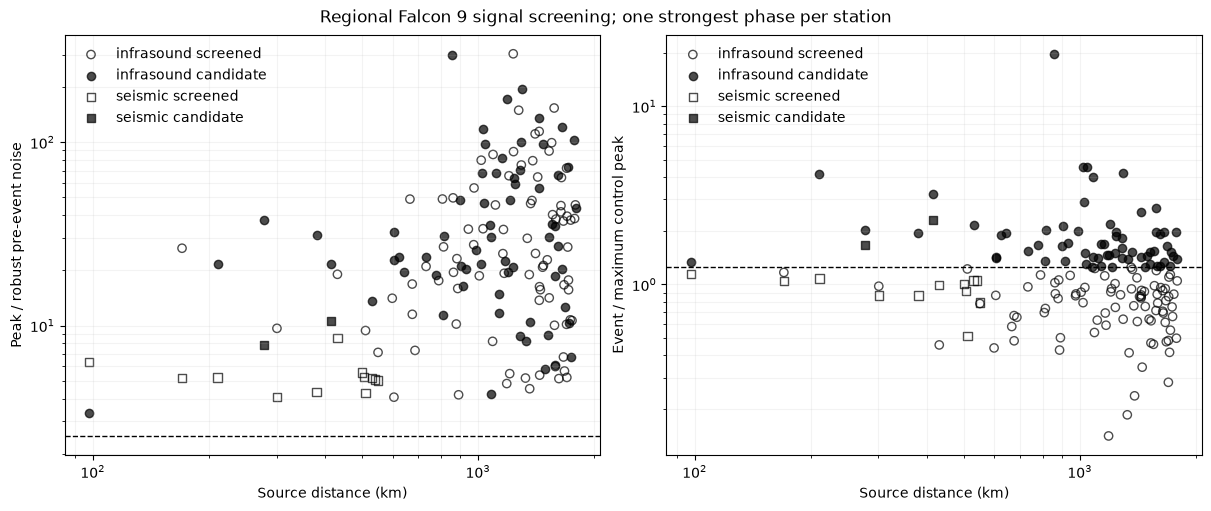

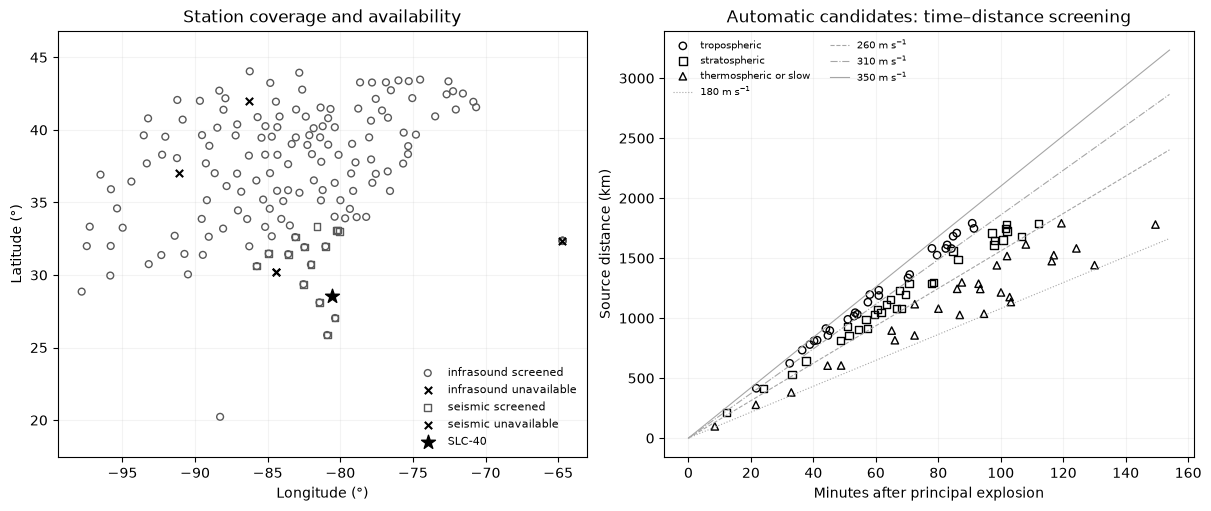

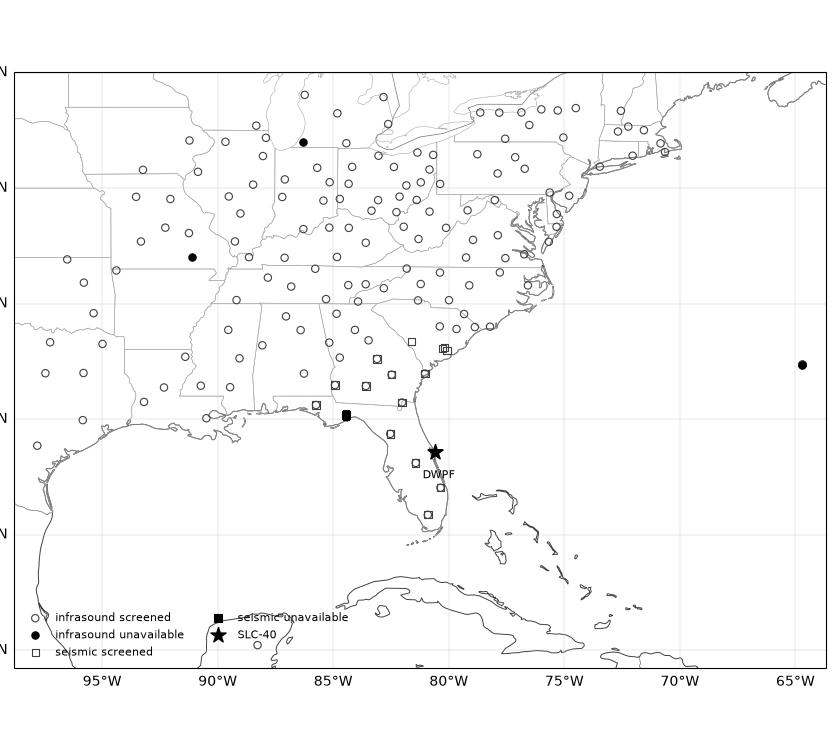

Audit PDF: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/145_analyze_regional_detectability/regional_station_waveform_audit.pdf


In [8]:
phase_gray = {
    "P_candidate": "0.92",
    "S_candidate": "0.86",
    "surface_candidate": "0.80",
    "ground_coupled_airwave": "0.72",
    "tropospheric": "0.88",
    "stratospheric": "0.80",
    "thermospheric_or_slow": "0.72",
}

audit_pdf = OUTPUT_ROOT / "regional_station_waveform_audit.pdf"
with PdfPages(audit_pdf) as pdf:
    for record in diagnostic_records:
        fig, ax = plt.subplots(figsize=(11, 5.5), constrained_layout=True)
        for phase_name, (start_s, end_s) in record["windows"].items():
            ax.axvspan(
                start_s,
                end_s,
                color=phase_gray.get(phase_name, "0.85"),
                alpha=0.55,
                label=phase_name.replace("_", " "),
            )
        ax.plot(
            record["time_s"],
            record["data"],
            color="black",
            lw=0.45,
            rasterized=False,
        )
        for metric in record["metrics"]:
            if metric.get("automatic_candidate", False):
                ax.axvline(
                    metric["peak_elapsed_from_source_s"],
                    color="black",
                    lw=1.2,
                    ls="--",
                )
        units = "Pa" if record["sensor_type"] == "infrasound" else "m s$^{-1}$"
        ax.set(
            xlabel=f"Time after {REFERENCE_EVENT_LABEL} source time (s)",
            ylabel=f"Filtered amplitude ({units})",
            title=(
                f"{record['network']}.{record['station']}."
                f"{record['location']}.{record['channel']} — "
                f"{record['sensor_type']}, {record['distance_km']:.1f} km, "
                f"azimuth {record['azimuth_deg']:.1f}°\n"
                f"screening band {record['band'][0]:g}–{record['band'][1]:g} Hz"
            ),
        )
        handles, labels = ax.get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        ax.legend(
            unique.values(),
            unique.keys(),
            frameon=False,
            fontsize=8,
            ncol=2,
            loc="upper right",
        )
        ax.grid(True, alpha=0.15)
        pdf.savefig(fig)
        plt.close(fig)

# Summary ranking.
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for sensor_type, marker in (("infrasound", "o"), ("seismic", "s")):
    sensor_subset = ranked.loc[ranked["sensor_type"] == sensor_type]
    for is_candidate, facecolor, suffix in (
        (False, "none", "screened"),
        (True, "black", "candidate"),
    ):
        subset = sensor_subset.loc[
            sensor_subset["automatic_candidate"].fillna(False).eq(is_candidate)
        ]
        for ax, y_column in zip(
            axes, ("peak_snr", "event_to_control_peak_ratio")
        ):
            ax.scatter(
                subset["distance_km"],
                subset[y_column],
                marker=marker,
                facecolors=facecolor,
                edgecolors="black",
                alpha=0.70,
                label=f"{sensor_type} {suffix}",
            )

axes[0].axhline(MIN_SNR, color="black", ls="--", lw=1)
axes[1].axhline(MIN_EVENT_TO_CONTROL_PEAK_RATIO, color="black", ls="--", lw=1)
axes[0].set(xlabel="Source distance (km)", ylabel="Peak / robust pre-event noise")
axes[1].set(xlabel="Source distance (km)", ylabel="Event / maximum control peak")
for ax in axes:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, which="both", alpha=0.15)
    ax.legend(frameon=False)
fig.suptitle(
    "Regional Falcon 9 signal screening; one strongest phase per station"
)
fig.savefig(
    OUTPUT_ROOT / "regional_detectability_screening_summary.pdf",
    bbox_inches="tight",
)
plt.show()

# Coverage and time-distance diagnostic for network-level review.
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for sensor_type, marker in (("infrasound", "o"), ("seismic", "s")):
    screened = availability.loc[
        availability["sensor_type"].eq(sensor_type)
        & availability["status"].eq("screened")
    ]
    failed = availability.loc[
        availability["sensor_type"].eq(sensor_type)
        & availability["status"].ne("screened")
    ]
    axes[0].scatter(
        screened["longitude"], screened["latitude"],
        marker=marker, facecolors="none", edgecolors="0.35",
        s=24, label=f"{sensor_type} screened",
    )
    axes[0].scatter(
        failed["longitude"], failed["latitude"],
        marker="x", color="black", s=28,
        label=f"{sensor_type} unavailable",
    )
axes[0].scatter(
    [SOURCE_LONGITUDE], [SOURCE_LATITUDE], marker="*",
    color="black", s=110, label="SLC-40", zorder=5,
)
axes[0].set(
    xlabel="Longitude (°)", ylabel="Latitude (°)",
    title="Station coverage and availability",
)
axes[0].set_aspect("equal", adjustable="datalim")
axes[0].grid(True, alpha=0.15)
axes[0].legend(frameon=False, fontsize=8)

candidate_metrics = metrics.loc[
    metrics["automatic_candidate"].fillna(False)
].copy()
for phase_name, marker in (
    ("tropospheric", "o"),
    ("stratospheric", "s"),
    ("thermospheric_or_slow", "^"),
):
    subset = candidate_metrics.loc[candidate_metrics["phase"].eq(phase_name)]
    axes[1].scatter(
        subset["peak_elapsed_from_source_s"] / 60.0,
        subset["distance_km"],
        marker=marker, facecolors="none", edgecolors="black",
        s=28, label=phase_name.replace("_", " "),
    )
if not candidate_metrics.empty:
    elapsed_minutes = np.linspace(0, (
        candidate_metrics["peak_elapsed_from_source_s"].max() / 60.0
    ) * 1.03, 300)
    for celerity, linestyle in ((180, ":"), (260, "--"), (310, "-."), (350, "-")):
        axes[1].plot(
            elapsed_minutes, elapsed_minutes * 60.0 * celerity / 1000.0,
            color="0.65", ls=linestyle, lw=0.8,
            label=f"{celerity} m s$^{{-1}}$",
        )
axes[1].set(
    xlabel=f"Minutes after {REFERENCE_EVENT_LABEL}",
    ylabel="Source distance (km)",
    title="Automatic candidates: time–distance screening",
)
axes[1].grid(True, alpha=0.15)
axes[1].legend(frameon=False, fontsize=7, ncol=2)
fig.savefig(
    OUTPUT_ROOT / "regional_station_coverage_and_candidate_moveout.pdf",
    bbox_inches="tight",
)
plt.show()

# Supplement-ready geographic station map. Cartopy adds coastlines and
# political boundaries when installed; the plain lon/lat fallback keeps
# the notebook runnable without an additional mapping dependency.
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    map_projection = ccrs.PlateCarree()
    fig = plt.figure(figsize=(8.2, 7.2), constrained_layout=True)
    map_ax = fig.add_subplot(1, 1, 1, projection=map_projection)
    map_ax.coastlines(resolution="50m", color="0.25", linewidth=0.7)
    map_ax.add_feature(cfeature.BORDERS, edgecolor="0.45", linewidth=0.5)
    map_ax.add_feature(cfeature.STATES, edgecolor="0.65", linewidth=0.4)
    map_transform = {"transform": ccrs.PlateCarree()}
    geographic_map = True
except ImportError:
    fig, map_ax = plt.subplots(figsize=(8.2, 7.2), constrained_layout=True)
    map_transform = {}
    geographic_map = False

for sensor_type, marker in (("infrasound", "o"), ("seismic", "s")):
    for status, edgecolor, facecolor, suffix in (
        ("screened", "0.25", "none", "screened"),
        ("failed", "black", "black", "unavailable"),
    ):
        subset = availability.loc[
            availability["sensor_type"].eq(sensor_type)
            & availability["status"].eq(status)
        ]
        map_ax.scatter(
            subset["longitude"], subset["latitude"],
            marker=marker, edgecolors=edgecolor, facecolors=facecolor,
            linewidths=0.8, s=28, label=f"{sensor_type} {suffix}",
            zorder=3, **map_transform,
        )
map_ax.scatter(
    [SOURCE_LONGITUDE], [SOURCE_LATITUDE], marker="*", color="black",
    s=130, label="SLC-40", zorder=5, **map_transform,
)
dwpf_rows = availability.loc[
    availability["network"].eq("IU")
    & availability["station"].eq("DWPF")
].drop_duplicates(["network", "station"])
if not dwpf_rows.empty:
    dwpf = dwpf_rows.iloc[0]
    map_ax.annotate(
        "DWPF", (dwpf["longitude"], dwpf["latitude"]),
        xytext=(5, -11), textcoords="offset points", fontsize=8,
        **map_transform,
    )
longitude_min = min(float(availability["longitude"].min()), SOURCE_LONGITUDE)
longitude_max = max(float(availability["longitude"].max()), SOURCE_LONGITUDE)
latitude_min = min(float(availability["latitude"].min()), SOURCE_LATITUDE)
latitude_max = max(float(availability["latitude"].max()), SOURCE_LATITUDE)
map_extent = [longitude_min - 1.0, longitude_max + 1.0, latitude_min - 1.0, latitude_max + 1.0]
if geographic_map:
    map_ax.set_extent(map_extent, crs=ccrs.PlateCarree())
    gridlines = map_ax.gridlines(
        draw_labels=True, linewidth=0.35, color="0.75", alpha=0.7
    )
    gridlines.top_labels = False
    gridlines.right_labels = False
else:
    map_ax.set_xlim(map_extent[:2])
    map_ax.set_ylim(map_extent[2:])
    map_ax.set_xlabel("Longitude (°)")
    map_ax.set_ylabel("Latitude (°)")
    map_ax.grid(True, alpha=0.15)
map_ax.set_title("Regional stations examined for the 2016 Falcon 9 failure")
map_ax.legend(frameon=False, fontsize=8, ncol=2, loc="lower left")
fig.savefig(
    OUTPUT_ROOT / "supplement_regional_station_map.pdf",
    bbox_inches="tight",
)
plt.show()

print("Audit PDF:", audit_pdf)


## Run metadata and interpretation guardrails

The JSON record captures the exact thresholds and search domains. A station with unavailable data or failed response removal is **not** a non-detection. A station passing the automatic threshold is **not** a confirmed detection. The final manuscript result must be derived from the completed manual-review CSV and should distinguish seismic phases from ground-coupled atmospheric arrivals.


In [9]:
run_metadata = {
    "notebook": "145_analyze_regional_detectability.ipynb",
    "reference_event_key": REFERENCE_EVENT_KEY,
    "reference_event_label": REFERENCE_EVENT_LABEL,
    "source_time_utc": SOURCE_TIME.isoformat(),
    "source_latitude": SOURCE_LATITUDE,
    "source_longitude": SOURCE_LONGITUDE,
    "source_geometry_provenance": SOURCE_GEOMETRY_PROVENANCE,
    "fdsn_provider": FDSN_PROVIDER,
    "acoustic_max_distance_km": ACOUSTIC_MAX_DISTANCE_KM,
    "seismic_max_distance_km": SEISMIC_MAX_DISTANCE_KM,
    "acoustic_channel_patterns": list(ACOUSTIC_CHANNEL_PATTERNS),
    "seismic_channel_patterns": list(SEISMIC_CHANNEL_PATTERNS),
    "acoustic_band_hz": list(ACOUSTIC_BAND_HZ),
    "seismic_band_hz": list(SEISMIC_BAND_HZ),
    "minimum_snr": MIN_SNR,
    "minimum_event_to_control_peak_ratio": MIN_EVENT_TO_CONTROL_PEAK_RATIO,
    "control_window_rule": "pre and post controls match each phase-window duration",
    "control_guard_s": CONTROL_GUARD_S,
    "acoustic_phase_celerities_mps": {
        key: list(value) for key, value in ACOUSTIC_PHASES_MPS.items()
    },
    "seismic_phase_velocities_mps": {
        key: list(value) for key, value in SEISMIC_PHASES_MPS.items()
    },
    "optional_station_manifest": (
        str(OPTIONAL_STATION_MANIFEST.relative_to(PROJECT_ROOT))
        if OPTIONAL_STATION_MANIFEST.exists() else None
    ),
    "target_count": int(len(targets)),
    "screened_count": int(availability["status"].eq("screened").sum()),
    "failed_count": int(availability["status"].eq("failed").sum()),
    "automatic_candidate_count": int(
        metrics["automatic_candidate"].fillna(False).sum()
    ),
    "automatic_candidate_station_count": int(
        metrics.loc[metrics["automatic_candidate"].fillna(False),
                    ["sensor_type", "network", "station"]]
        .drop_duplicates().shape[0]
    ),
    "interpretation_warning": (
        "Automatic candidates require manual review. Missing data and response "
        "failures are not non-detections. Do not infer a regional null result "
        "until regional_candidate_manual_review.csv is completed. A confirmed "
        "regional detection also requires a physically consistent multi-station branch."
    ),
}
(OUTPUT_ROOT / "regional_detectability_run_metadata.json").write_text(
    json.dumps(run_metadata, indent=2) + "\n",
    encoding="utf-8",
)

print(json.dumps(run_metadata, indent=2))
print("\nRequired final step: complete regional_candidate_manual_review.csv")


{
  "notebook": "145_analyze_regional_detectability.ipynb",
  "reference_event_key": "lower_stage",
  "reference_event_label": "principal explosion",
  "source_time_utc": "2016-09-01T13:07:15.513600",
  "source_latitude": 28.56193580144674,
  "source_longitude": -80.57720517592954,
  "source_geometry_provenance": "data/outputs/010_prepare_analysis_inputs/analysis_configuration.json",
  "fdsn_provider": "EARTHSCOPE",
  "acoustic_max_distance_km": 1800.0,
  "seismic_max_distance_km": 600.0,
  "acoustic_channel_patterns": [
    "?DF",
    "?DO"
  ],
  "seismic_channel_patterns": [
    "HHZ",
    "BHZ",
    "LHZ"
  ],
  "acoustic_band_hz": [
    0.2,
    1.0
  ],
  "seismic_band_hz": [
    0.5,
    5.0
  ],
  "minimum_snr": 2.5,
  "minimum_event_to_control_peak_ratio": 1.25,
  "control_window_rule": "pre and post controls match each phase-window duration",
  "control_guard_s": 120.0,
  "acoustic_phase_celerities_mps": {
    "tropospheric": [
      310.0,
      350.0
    ],
    "stratospher

## Focused review of the strongest northern infrasound candidates

This diagnostic reloads the complete cached records for N4.257A, N4.S54A, and N4.R55A. For each station it selects the automatically flagged phase having the largest event-to-control peak ratio; if no phase remains automatically flagged after a rerun, it selects the strongest measured phase for inspection. The upper panel is response-corrected but otherwise unfiltered pressure, and the lower panel is the screening-band waveform. These displays support artifact and waveform-morphology review; they do not by themselves confirm a Falcon 9 detection.


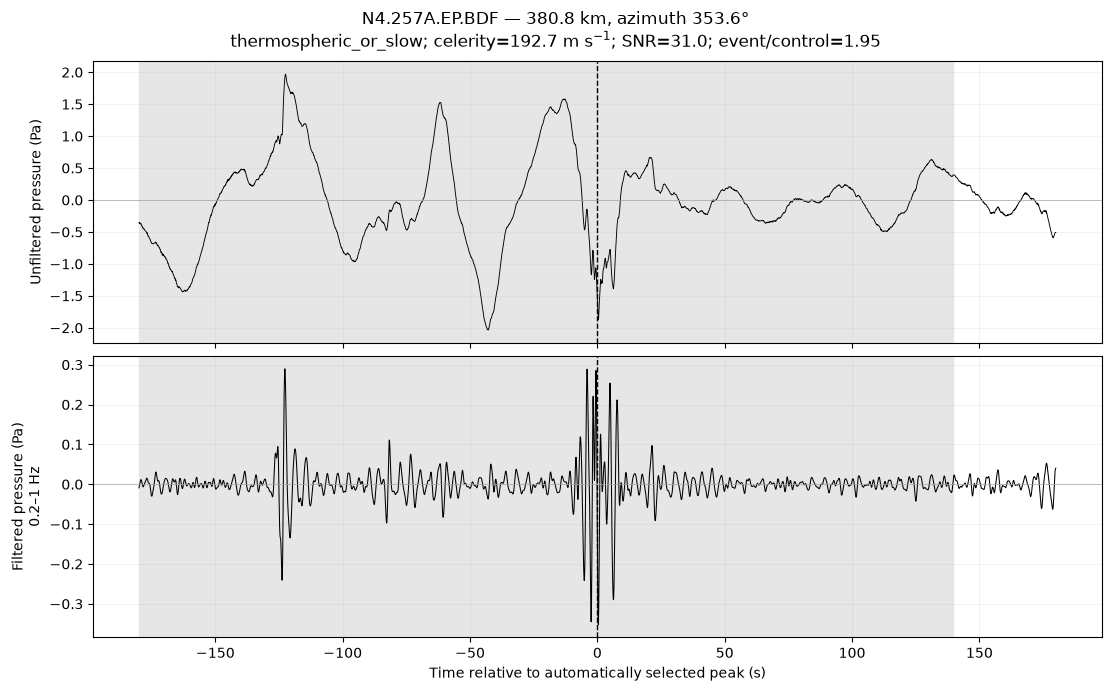

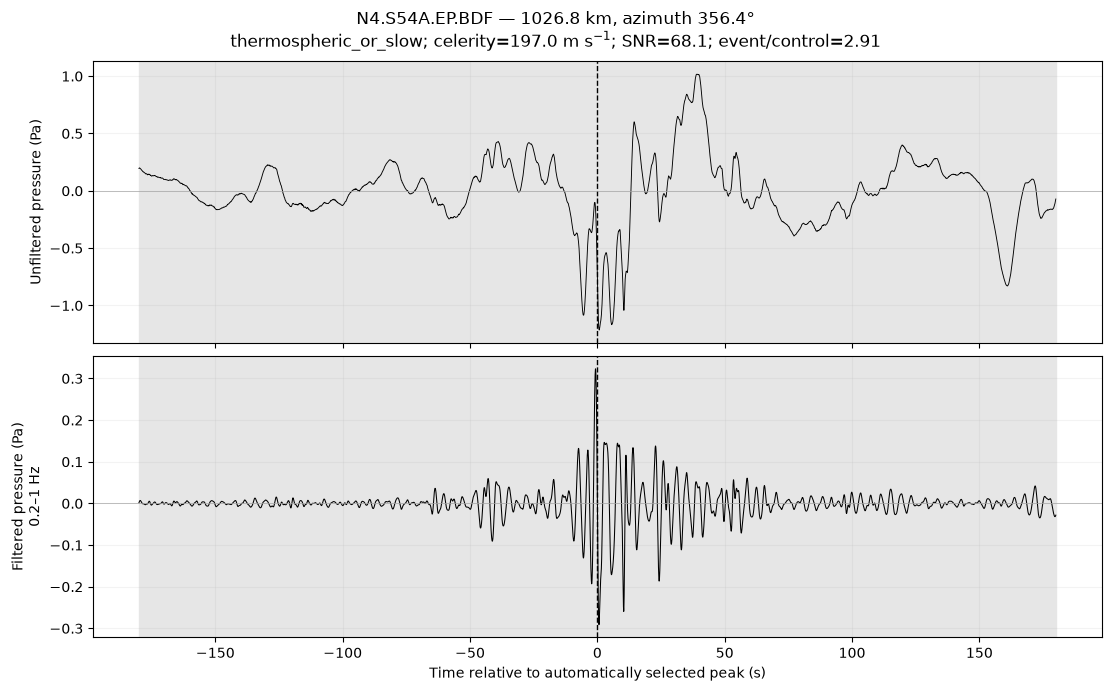

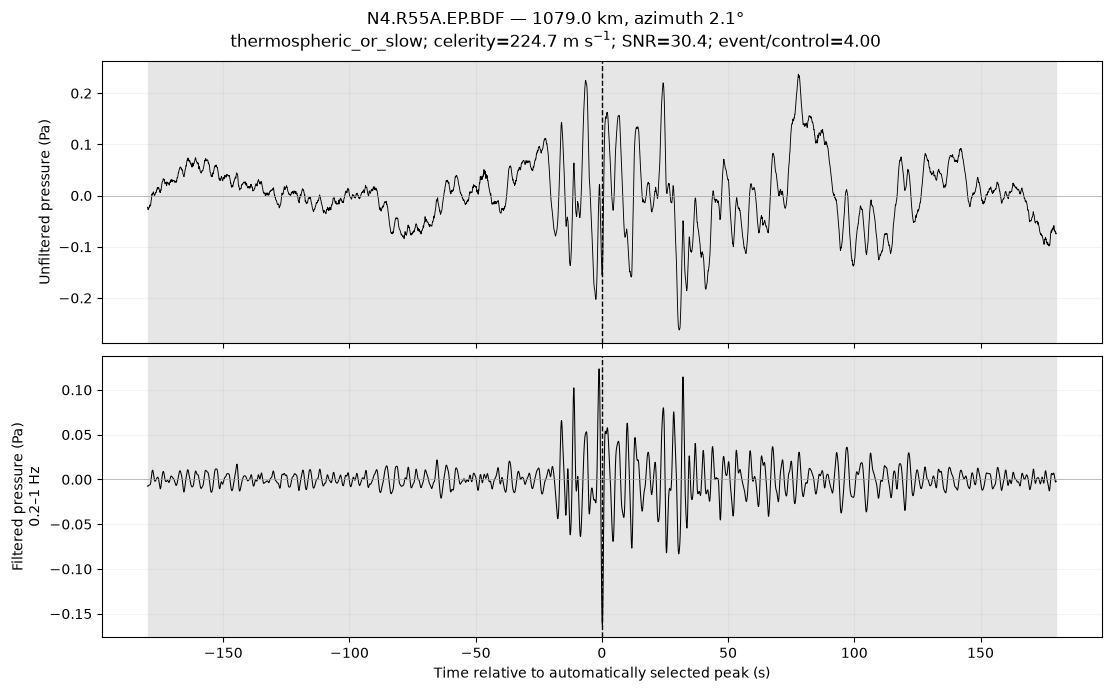

Candidate zoom PDF: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/145_analyze_regional_detectability/regional_best_candidate_zoom_audit.pdf


,network,station,location,channel,phase,peak_time_utc,apparent_speed_mps,peak_snr,event_to_control_peak_ratio
17,N4,257A,EP,BDF,thermospheric_or_slow,2016-09-01T13:40:11.331640,192.717489,31.040322,1.946963
143,N4,S54A,EP,BDF,thermospheric_or_slow,2016-09-01T14:34:08.105979,196.988839,68.120660,2.905962
161,N4,R55A,EP,BDF,thermospheric_or_slow,2016-09-01T14:27:18.360087,224.652837,30.440796,3.995391


In [10]:
BEST_CANDIDATE_STATIONS = (
    ("N4", "257A"),
    ("N4", "S54A"),
    ("N4", "R55A"),
)
CANDIDATE_ZOOM_HALF_WIDTH_S = 180.0

selected_candidate_rows = []
for network_code, station_code in BEST_CANDIDATE_STATIONS:
    station_metrics = metrics.loc[
        metrics["sensor_type"].eq("infrasound")
        & metrics["network"].eq(network_code)
        & metrics["station"].eq(station_code)
    ].copy()
    if station_metrics.empty:
        print(f"No measurements found for {network_code}.{station_code}")
        continue
    flagged = station_metrics.loc[
        station_metrics["automatic_candidate"].fillna(False)
    ]
    review_pool = flagged if not flagged.empty else station_metrics
    review_pool = review_pool.assign(
        _ratio=pd.to_numeric(
            review_pool["event_to_control_peak_ratio"], errors="coerce"
        ),
        _snr=pd.to_numeric(review_pool["peak_snr"], errors="coerce"),
    ).sort_values(
        ["_ratio", "_snr"], ascending=False, na_position="last"
    )
    selected_candidate_rows.append(
        review_pool.iloc[0].drop(labels=["_ratio", "_snr"])
    )

if not selected_candidate_rows:
    raise RuntimeError("None of the requested candidate stations was measured")

selected_candidate_metrics = pd.DataFrame(selected_candidate_rows)
selected_candidate_metrics.to_csv(
    OUTPUT_ROOT / "regional_best_candidate_zoom_metrics.csv", index=False
)

candidate_zoom_pdf = OUTPUT_ROOT / "regional_best_candidate_zoom_audit.pdf"
with PdfPages(candidate_zoom_pdf) as pdf:
    for _, candidate in selected_candidate_metrics.iterrows():
        availability_match = availability.loc[
            availability["sensor_type"].eq("infrasound")
            & availability["network"].eq(str(candidate.network))
            & availability["station"].eq(str(candidate.station))
            & availability["status"].eq("screened")
        ]
        if availability_match.empty:
            print(f"No screened waveform for {candidate.network}.{candidate.station}")
            continue

        target_row = availability_match.iloc[0].copy()
        request_start = UTCDateTime(target_row.request_start_utc)
        request_end = UTCDateTime(target_row.request_end_utc)
        raw_counts, selected_row, _ = retrieve_trace(
            target_row, request_start, request_end
        )
        response_inventory = response_inventory_for(
            selected_row, raw_counts.stats.starttime, raw_counts.stats.endtime
        )
        unfiltered_pressure = remove_response_physical(
            raw_counts, response_inventory, "infrasound"
        )
        filtered_pressure, effective_band = filtered_trace(
            unfiltered_pressure, ACOUSTIC_BAND_HZ
        )
        #unfiltered_pressure, effective_band = filtered_trace(
        #    unfiltered_pressure, (0.15, 50.0)
        #)

        peak_time = UTCDateTime(candidate.peak_time_utc)
        zoom_start = peak_time - CANDIDATE_ZOOM_HALF_WIDTH_S
        zoom_end = peak_time + CANDIDATE_ZOOM_HALF_WIDTH_S
        raw_zoom = unfiltered_pressure.slice(
            zoom_start, zoom_end, nearest_sample=False
        )
        filtered_zoom = filtered_pressure.slice(
            zoom_start, zoom_end, nearest_sample=False
        )

        def relative_time(trace: Trace, reference: UTCDateTime) -> np.ndarray:
            return (
                float(trace.stats.starttime - reference)
                + np.arange(trace.stats.npts) / float(trace.stats.sampling_rate)
            )

        raw_time = relative_time(raw_zoom, peak_time)
        filtered_time = relative_time(filtered_zoom, peak_time)
        fig, axes = plt.subplots(
            2, 1, figsize=(11, 6.8), sharex=True, constrained_layout=True
        )
        axes[0].plot(raw_time, raw_zoom.data, color="black", lw=0.65)
        axes[1].plot(
            filtered_time, filtered_zoom.data, color="black", lw=0.75
        )

        phase_start_relative = float(UTCDateTime(candidate.phase_start_utc) - peak_time)
        phase_end_relative = float(UTCDateTime(candidate.phase_end_utc) - peak_time)
        for ax in axes:
            ax.axvspan(
                max(-CANDIDATE_ZOOM_HALF_WIDTH_S, phase_start_relative),
                min(CANDIDATE_ZOOM_HALF_WIDTH_S, phase_end_relative),
                color="0.90", zorder=0, label=str(candidate.phase).replace("_", " "),
            )
            ax.axvline(0.0, color="black", ls="--", lw=1.0)
            ax.axhline(0.0, color="0.65", lw=0.5)
            ax.grid(True, alpha=0.15)
        axes[0].set_ylabel("Unfiltered pressure (Pa)")
        axes[1].set_ylabel(
            f"Filtered pressure (Pa)\n{effective_band[0]:g}–{effective_band[1]:g} Hz"
        )
        axes[1].set_xlabel("Time relative to automatically selected peak (s)")
        fig.suptitle(
            f"{selected_row.network}.{selected_row.station}."
            f"{selected_row.location}.{selected_row.channel} — "
            f"{float(candidate.distance_km):.1f} km, "
            f"azimuth {float(candidate.source_to_station_azimuth_deg):.1f}°\n"
            f"{candidate.phase}; celerity={float(candidate.apparent_speed_mps):.1f} m s$^{{-1}}$; "
            f"SNR={float(candidate.peak_snr):.1f}; "
            f"event/control={float(candidate.event_to_control_peak_ratio):.2f}"
        )
        pdf.savefig(fig, bbox_inches="tight")
        plt.show()
        plt.close(fig)

print("Candidate zoom PDF:", candidate_zoom_pdf)
display(selected_candidate_metrics[[
    "network", "station", "location", "channel", "phase",
    "peak_time_utc", "apparent_speed_mps", "peak_snr",
    "event_to_control_peak_ratio",
]])


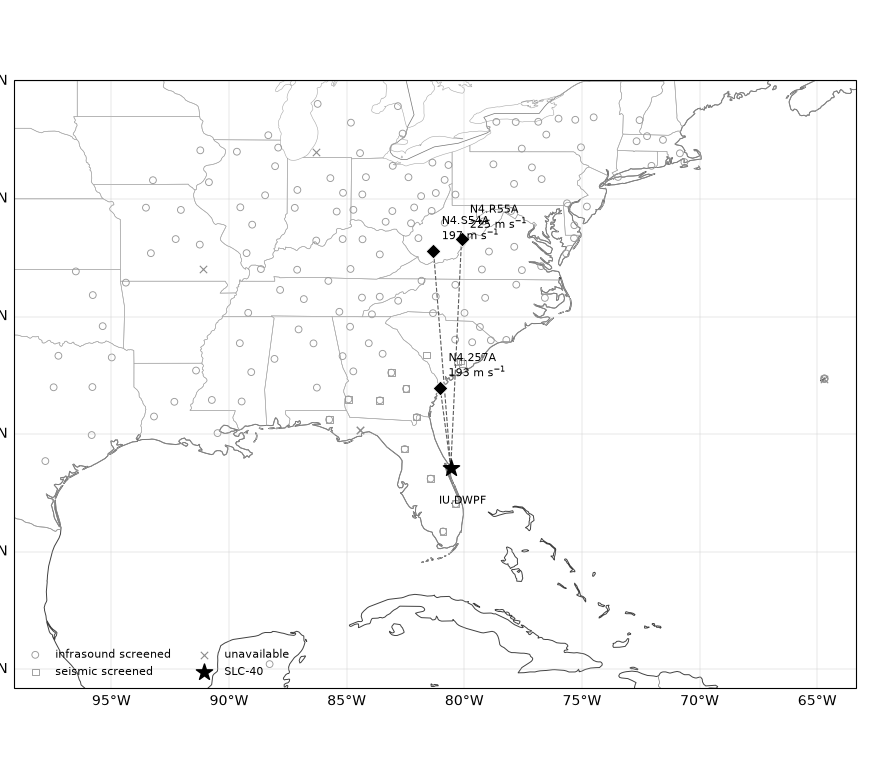

Candidate station map: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/145_analyze_regional_detectability/supplement_regional_station_map_best_candidates.pdf


,network,station,channel,distance_km,source_to_station_azimuth_deg,status
5,N4,257A,BDF,380.774690,353.598564,screened
48,N4,S54A,BDF,1026.822519,356.373966,screened
54,N4,R55A,BDF,1078.973087,2.137245,screened


In [11]:
# Supplementary map highlighting the three strongest regional candidates.

MAP_CANDIDATE_STATIONS = (
    ("N4", "257A"),
    ("N4", "S54A"),
    ("N4", "R55A"),
)

map_candidates = availability.loc[
    pd.MultiIndex.from_frame(
        availability[["network", "station"]]
    ).isin(MAP_CANDIDATE_STATIONS)
].drop_duplicates(["network", "station"]).copy()

missing_candidates = [
    f"{network}.{station}"
    for network, station in MAP_CANDIDATE_STATIONS
    if not (
        map_candidates["network"].eq(network)
        & map_candidates["station"].eq(station)
    ).any()
]
if missing_candidates:
    raise RuntimeError(
        "Candidate stations missing from availability table: "
        + ", ".join(missing_candidates)
    )

# Obtain the strongest candidate celerity for each highlighted station.
candidate_labels = {}
for network, station in MAP_CANDIDATE_STATIONS:
    station_metrics = metrics.loc[
        metrics["network"].eq(network)
        & metrics["station"].eq(station)
        & metrics["sensor_type"].eq("infrasound")
    ].copy()

    flagged = station_metrics.loc[
        station_metrics["automatic_candidate"].fillna(False)
    ]
    review_pool = flagged if not flagged.empty else station_metrics

    if not review_pool.empty:
        strongest = (
            review_pool.assign(
                _ratio=pd.to_numeric(
                    review_pool["event_to_control_peak_ratio"],
                    errors="coerce",
                ),
                _snr=pd.to_numeric(
                    review_pool["peak_snr"],
                    errors="coerce",
                ),
            )
            .sort_values(
                ["_ratio", "_snr"],
                ascending=False,
                na_position="last",
            )
            .iloc[0]
        )
        candidate_labels[(network, station)] = (
            f"{network}.{station}\n"
            f"{float(strongest['apparent_speed_mps']):.0f} m s$^{{-1}}$"
        )
    else:
        candidate_labels[(network, station)] = f"{network}.{station}"

# Use one row per network/station/sensor type for background plotting.
station_map_table = availability.drop_duplicates(
    ["sensor_type", "network", "station"]
).copy()

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    geographic_map = True
    map_projection = ccrs.PlateCarree()

    fig = plt.figure(figsize=(8.5, 7.5), constrained_layout=True)
    ax = fig.add_subplot(1, 1, 1, projection=map_projection)

    ax.coastlines(
        resolution="50m",
        color="0.25",
        linewidth=0.7,
    )
    ax.add_feature(
        cfeature.BORDERS,
        edgecolor="0.45",
        linewidth=0.5,
    )
    ax.add_feature(
        cfeature.STATES,
        edgecolor="0.65",
        linewidth=0.4,
    )

    point_transform = {"transform": ccrs.PlateCarree()}
    path_transform = {"transform": ccrs.Geodetic()}

except ImportError:
    geographic_map = False
    fig, ax = plt.subplots(
        figsize=(8.5, 7.5),
        constrained_layout=True,
    )
    point_transform = {}
    path_transform = {}

# Screened background stations.
for sensor_type, marker in (
    ("infrasound", "o"),
    ("seismic", "s"),
):
    screened = station_map_table.loc[
        station_map_table["sensor_type"].eq(sensor_type)
        & station_map_table["status"].eq("screened")
    ]

    ax.scatter(
        screened["longitude"],
        screened["latitude"],
        marker=marker,
        s=24,
        facecolors="none",
        edgecolors="0.60",
        linewidths=0.65,
        label=f"{sensor_type} screened",
        zorder=2,
        **point_transform,
    )

# Unavailable or failed targets.
failed = station_map_table.loc[
    station_map_table["status"].ne("screened")
]
ax.scatter(
    failed["longitude"],
    failed["latitude"],
    marker="x",
    s=28,
    color="0.55",
    linewidths=0.8,
    label="unavailable",
    zorder=2,
    **point_transform,
)

# SLC-40 source.
ax.scatter(
    [SOURCE_LONGITUDE],
    [SOURCE_LATITUDE],
    marker="*",
    s=150,
    color="black",
    label="SLC-40",
    zorder=6,
    **point_transform,
)

# Highlight candidate stations and draw source-to-station paths.
for _, station_row in map_candidates.iterrows():
    network = str(station_row["network"])
    station = str(station_row["station"])
    longitude = float(station_row["longitude"])
    latitude = float(station_row["latitude"])

    ax.plot(
        [SOURCE_LONGITUDE, longitude],
        [SOURCE_LATITUDE, latitude],
        color="0.35",
        linewidth=0.8,
        linestyle="--",
        zorder=3,
        **path_transform,
    )

    ax.scatter(
        [longitude],
        [latitude],
        marker="D",
        s=58,
        facecolors="black",
        edgecolors="white",
        linewidths=0.7,
        zorder=7,
        **point_transform,
    )

    label = candidate_labels[(network, station)]
    ax.annotate(
        label,
        xy=(longitude, latitude),
        xytext=(6, 5),
        textcoords="offset points",
        fontsize=8,
        ha="left",
        va="bottom",
        zorder=8,
    )

# Label DWPF for context.
dwpf = station_map_table.loc[
    station_map_table["network"].eq("IU")
    & station_map_table["station"].eq("DWPF")
].drop_duplicates(["network", "station"])

if not dwpf.empty:
    dwpf_row = dwpf.iloc[0]
    ax.annotate(
        "IU.DWPF",
        xy=(
            float(dwpf_row["longitude"]),
            float(dwpf_row["latitude"]),
        ),
        xytext=(6, -12),
        textcoords="offset points",
        fontsize=8,
        ha="left",
        va="top",
        zorder=8,
    )

# Map extent based on all searched stations.
longitude_min = min(
    float(station_map_table["longitude"].min()),
    SOURCE_LONGITUDE,
)
longitude_max = max(
    float(station_map_table["longitude"].max()),
    SOURCE_LONGITUDE,
)
latitude_min = min(
    float(station_map_table["latitude"].min()),
    SOURCE_LATITUDE,
)
latitude_max = max(
    float(station_map_table["latitude"].max()),
    SOURCE_LATITUDE,
)

longitude_padding = max(
    1.0,
    0.04 * (longitude_max - longitude_min),
)
latitude_padding = max(
    1.0,
    0.04 * (latitude_max - latitude_min),
)

map_extent = [
    longitude_min - longitude_padding,
    longitude_max + longitude_padding,
    latitude_min - latitude_padding,
    latitude_max + latitude_padding,
]

if geographic_map:
    ax.set_extent(
        map_extent,
        crs=ccrs.PlateCarree(),
    )
    gridlines = ax.gridlines(
        draw_labels=True,
        linewidth=0.35,
        color="0.75",
        alpha=0.7,
    )
    gridlines.top_labels = False
    gridlines.right_labels = False
else:
    ax.set_xlim(map_extent[:2])
    ax.set_ylim(map_extent[2:])
    ax.set_xlabel("Longitude (°)")
    ax.set_ylabel("Latitude (°)")
    ax.grid(True, alpha=0.15)

ax.set_title(
    "Regional stations examined and strongest infrasound candidates"
)
ax.legend(
    frameon=False,
    fontsize=8,
    ncol=2,
    loc="lower left",
)

candidate_map_file = (
    OUTPUT_ROOT
    / "supplement_regional_station_map_best_candidates.pdf"
)
fig.savefig(
    candidate_map_file,
    bbox_inches="tight",
)
plt.show()

print("Candidate station map:", candidate_map_file)
display(
    map_candidates[
        [
            "network",
            "station",
            "channel",
            "distance_km",
            "source_to_station_azimuth_deg",
            "status",
        ]
    ]
)

## Focused regional-candidate audit

These cells are intended to follow the existing Notebook 145 screening and
map cells.  They do not convert automatic candidates into detections.  They
add raw-count checks, a source-time-constrained moveout test, a deliberately
labelled post-hoc pseudo-origin test, a northern-corridor record section, a
local BCHH comparison in the identical 0.2--1 Hz band, and a guarded
New-Glenn-style period/yield worksheet.



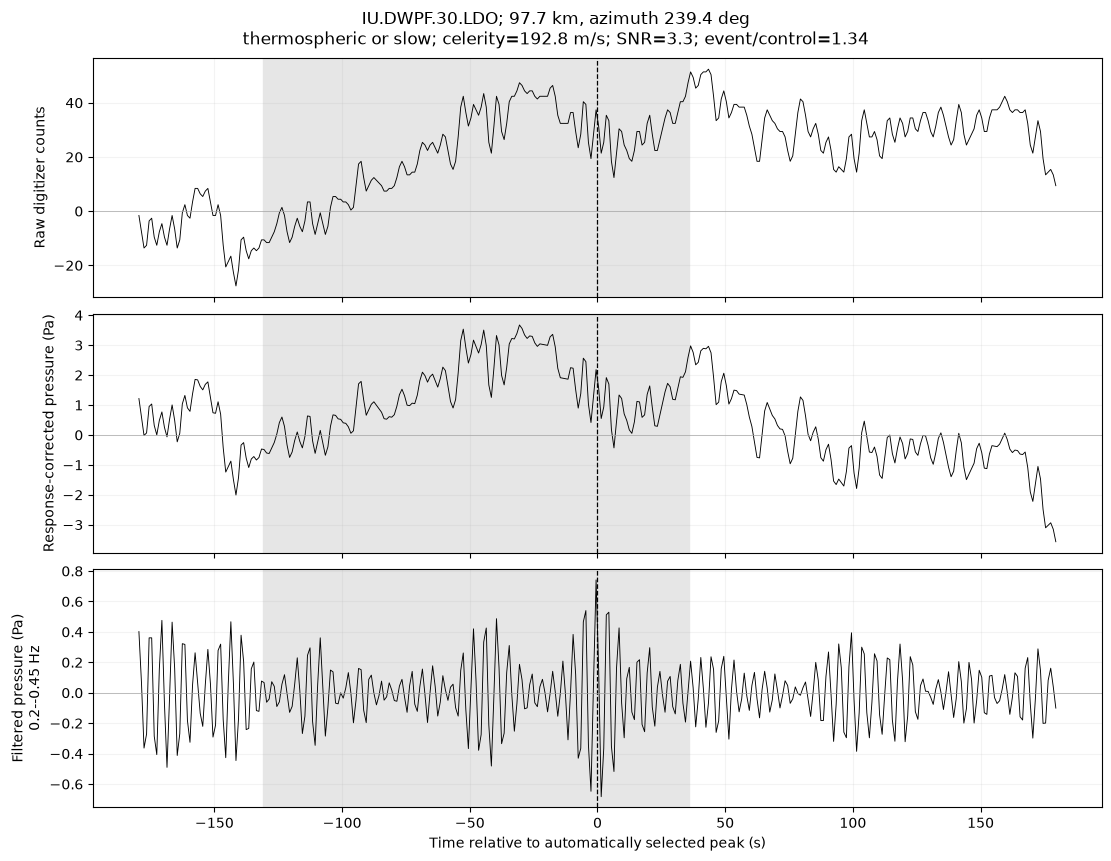

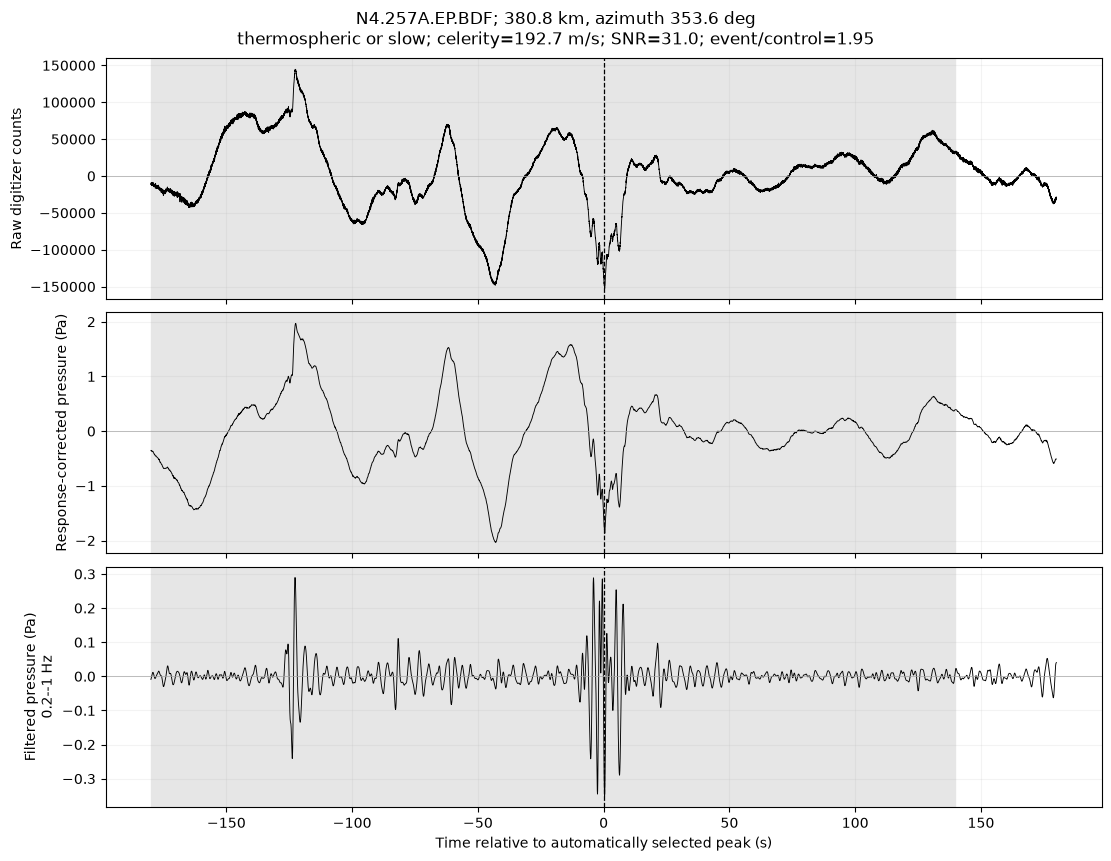

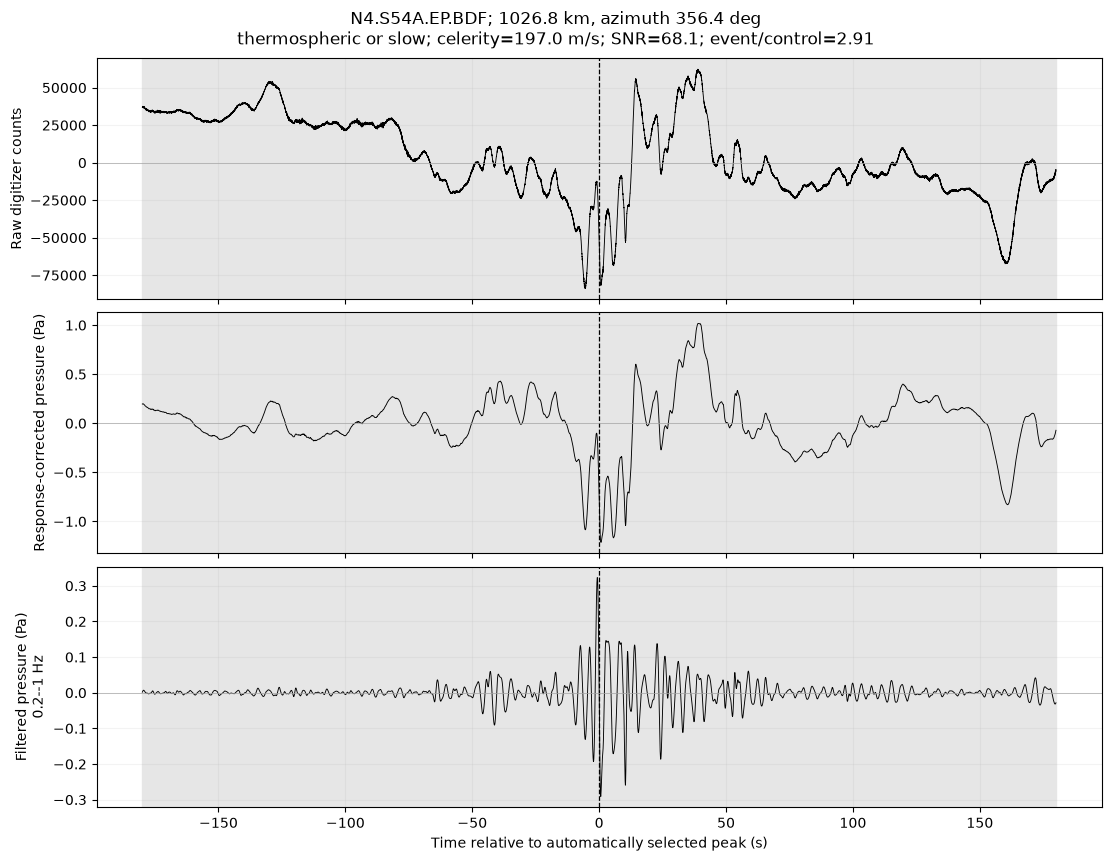

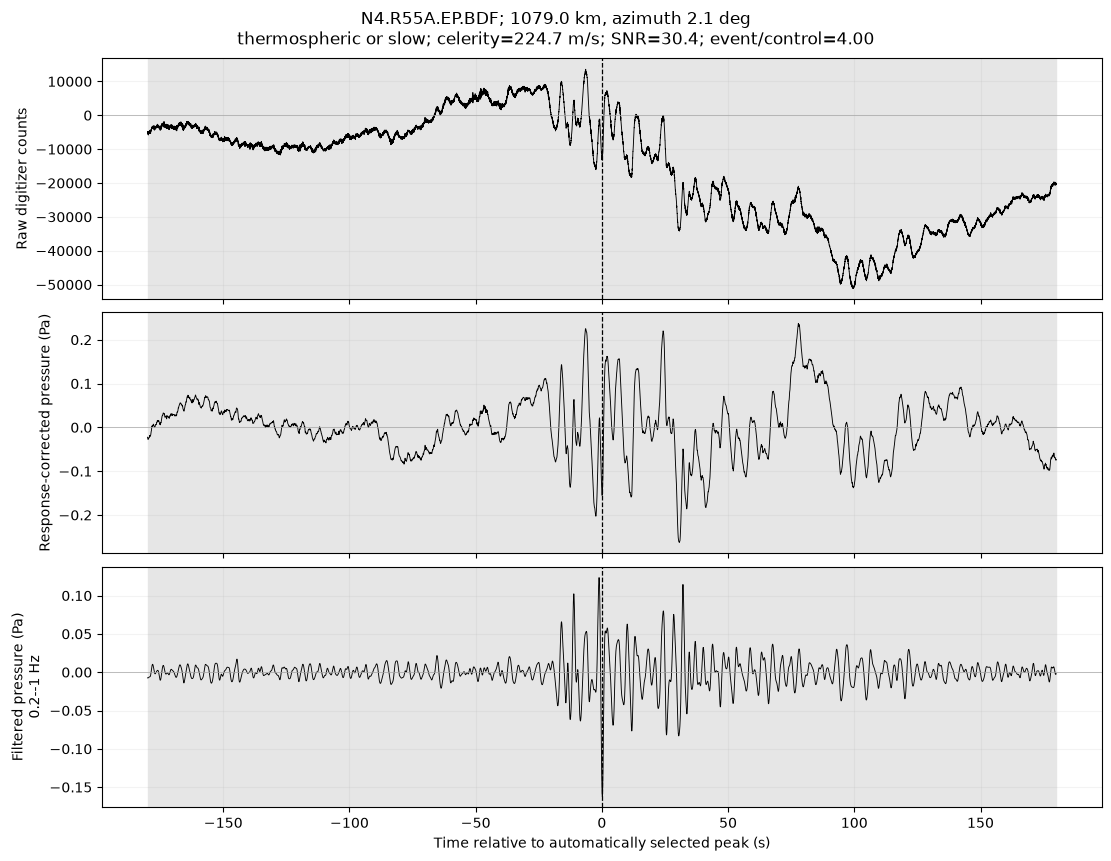

Focused raw/pressure audit: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/145_analyze_regional_detectability/145_focused_candidate_raw_and_pressure_audit.pdf


,network,station,location,channel,phase,distance_km,source_to_station_azimuth_deg,peak_time_utc,peak_elapsed_from_source_s,apparent_speed_mps,peak_snr,event_to_control_peak_ratio
0,IU,DWPF,30,LDO,thermospheric_or_slow,97.682827,239.380046,2016-09-01T13:15:42.216782,506.703182,192.781160,3.333691,1.343209
1,N4,257A,EP,BDF,thermospheric_or_slow,380.774690,353.598564,2016-09-01T13:40:11.331640,1975.818040,192.717489,31.040322,1.946963
2,N4,S54A,EP,BDF,thermospheric_or_slow,1026.822519,356.373966,2016-09-01T14:34:08.105979,5212.592379,196.988839,68.120660,2.905962
3,N4,R55A,EP,BDF,thermospheric_or_slow,1078.973087,2.137245,2016-09-01T14:27:18.360087,4802.846487,224.652837,30.440796,3.995391


In [12]:
from obspy import read

FOCUSED_REGIONAL_STATIONS = (
    ("IU", "DWPF"),
    ("N4", "257A"),
    ("N4", "S54A"),
    ("N4", "R55A"),
)

# DWPF, 257A, and S54A define the visually selected slow branch.  R55A is
# retained as a separate candidate because its implied celerity is appreciably
# faster.  This grouping is post hoc and must be tested on independent sites.
POSTHOC_SLOW_BRANCH = (
    ("IU", "DWPF"),
    ("N4", "257A"),
    ("N4", "S54A"),
)

FOCUSED_ZOOM_HALF_WIDTH_S = 180.0


def strongest_infrasound_candidate(network: str, station: str) -> pd.Series:
    subset = metrics.loc[
        metrics["sensor_type"].eq("infrasound")
        & metrics["network"].eq(network)
        & metrics["station"].eq(station)
    ].copy()
    if subset.empty:
        raise KeyError(f"No infrasound metrics for {network}.{station}")
    automatic = subset.loc[subset["automatic_candidate"].fillna(False)]
    pool = automatic if not automatic.empty else subset
    pool["_ratio"] = pd.to_numeric(
        pool["event_to_control_peak_ratio"], errors="coerce"
    )
    pool["_snr"] = pd.to_numeric(pool["peak_snr"], errors="coerce")
    return (
        pool.sort_values(
            ["_ratio", "_snr"], ascending=False, na_position="last"
        )
        .iloc[0]
        .drop(labels=["_ratio", "_snr"])
    )


focused_rows = []
for network_code, station_code in FOCUSED_REGIONAL_STATIONS:
    try:
        focused_rows.append(
            strongest_infrasound_candidate(network_code, station_code)
        )
    except KeyError as exc:
        print(exc)

focused_candidate_metrics = pd.DataFrame(focused_rows).reset_index(drop=True)
if focused_candidate_metrics.empty:
    raise RuntimeError("None of the four focused stations has usable metrics")

focused_candidate_metrics.to_csv(
    OUTPUT_ROOT / "145_focused_regional_candidate_metrics.csv", index=False
)

focused_waveforms = {}
focused_audit_pdf = OUTPUT_ROOT / "145_focused_candidate_raw_and_pressure_audit.pdf"

with PdfPages(focused_audit_pdf) as pdf:
    for candidate in focused_candidate_metrics.itertuples(index=False):
        available = availability.loc[
            availability["sensor_type"].eq("infrasound")
            & availability["network"].eq(str(candidate.network))
            & availability["station"].eq(str(candidate.station))
            & availability["status"].eq("screened")
        ]
        if available.empty:
            print(f"No screened waveform for {candidate.network}.{candidate.station}")
            continue

        target_row = available.iloc[0].copy()
        request_start = UTCDateTime(target_row.request_start_utc)
        request_end = UTCDateTime(target_row.request_end_utc)
        counts, selected_row, attempts = retrieve_trace(
            target_row, request_start, request_end
        )
        counts = counts.copy().detrend("demean")
        response_inventory = response_inventory_for(
            selected_row, counts.stats.starttime, counts.stats.endtime
        )
        pressure = remove_response_physical(
            counts, response_inventory, "infrasound"
        )
        pressure_02_1, effective_band = filtered_trace(
            pressure, ACOUSTIC_BAND_HZ
        )

        key = (str(candidate.network), str(candidate.station))
        focused_waveforms[key] = {
            "counts": counts,
            "pressure": pressure,
            "filtered": pressure_02_1,
            "selected_row": selected_row,
            "candidate": pd.Series(candidate._asdict()),
            "effective_band": effective_band,
            "retrieval_attempts": attempts,
        }

        peak_time = UTCDateTime(candidate.peak_time_utc)
        zoom_start = peak_time - FOCUSED_ZOOM_HALF_WIDTH_S
        zoom_end = peak_time + FOCUSED_ZOOM_HALF_WIDTH_S
        traces = [
            counts.slice(zoom_start, zoom_end, nearest_sample=False),
            pressure.slice(zoom_start, zoom_end, nearest_sample=False),
            pressure_02_1.slice(zoom_start, zoom_end, nearest_sample=False),
        ]

        fig, axes = plt.subplots(
            3, 1, figsize=(11, 8.5), sharex=True, constrained_layout=True
        )
        labels = (
            "Raw digitizer counts",
            "Response-corrected pressure (Pa)",
            f"Filtered pressure (Pa)\n{effective_band[0]:g}--{effective_band[1]:g} Hz",
        )
        phase_start = float(UTCDateTime(candidate.phase_start_utc) - peak_time)
        phase_end = float(UTCDateTime(candidate.phase_end_utc) - peak_time)

        for ax, trace, label in zip(axes, traces, labels):
            times = (
                float(trace.stats.starttime - peak_time)
                + np.arange(trace.stats.npts) / float(trace.stats.sampling_rate)
            )
            ax.plot(times, trace.data, color="black", lw=0.65)
            ax.axvspan(
                max(-FOCUSED_ZOOM_HALF_WIDTH_S, phase_start),
                min(FOCUSED_ZOOM_HALF_WIDTH_S, phase_end),
                color="0.90", zorder=0,
            )
            ax.axvline(0.0, color="black", ls="--", lw=0.9)
            ax.axhline(0.0, color="0.65", lw=0.5)
            ax.set_ylabel(label)
            ax.grid(True, alpha=0.15)

        axes[-1].set_xlabel("Time relative to automatically selected peak (s)")
        fig.suptitle(
            f"{selected_row.network}.{selected_row.station}."
            f"{selected_row.location}.{selected_row.channel}; "
            f"{float(candidate.distance_km):.1f} km, "
            f"azimuth {float(candidate.source_to_station_azimuth_deg):.1f} deg\n"
            f"{str(candidate.phase).replace('_', ' ')}; "
            f"celerity={float(candidate.apparent_speed_mps):.1f} m/s; "
            f"SNR={float(candidate.peak_snr):.1f}; "
            f"event/control={float(candidate.event_to_control_peak_ratio):.2f}"
        )
        pdf.savefig(fig, bbox_inches="tight")
        plt.show()
        plt.close(fig)

print("Focused raw/pressure audit:", focused_audit_pdf)
display(
    focused_candidate_metrics[
        [
            "network", "station", "location", "channel", "phase",
            "distance_km", "source_to_station_azimuth_deg", "peak_time_utc",
            "peak_elapsed_from_source_s", "apparent_speed_mps", "peak_snr",
            "event_to_control_peak_ratio",
        ]
    ]
)




## Fixed-source moveout and leave-one-out timing test

A genuine common acoustic branch should approximately follow
\(t_i=r_i/c+t_0\).  The fixed-origin fit tests the independently known Falcon
9 source time.  The free-intercept fit checks whether the selected peaks imply
an origin offset near zero.  With only three post-hoc selected stations this
is a diagnostic, not a formal association test.



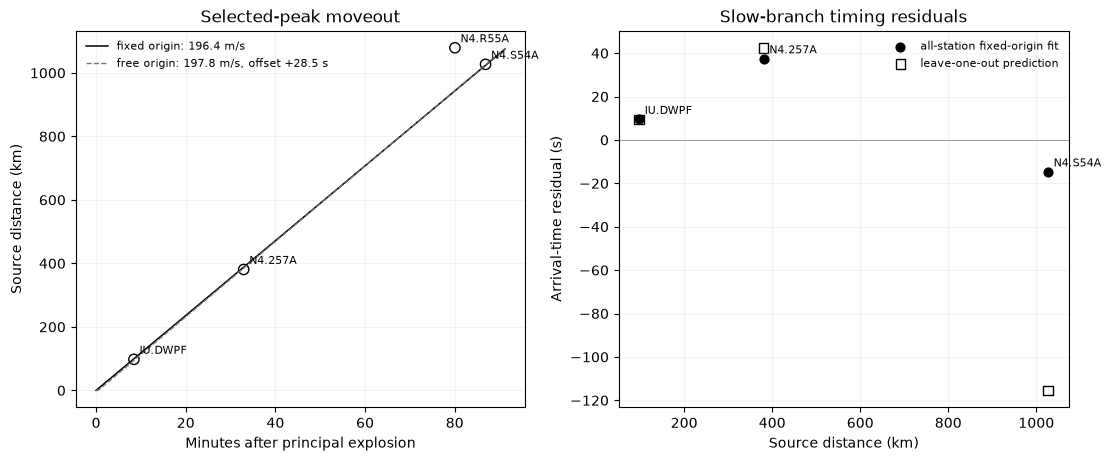

Fixed-origin celerity: 196.43 m/s
Free-origin solution: 197.81 m/s, origin offset +28.46 s


,network,station,distance_km,peak_elapsed_from_source_s,fixed_origin_residual_s,free_origin_residual_s
0,IU,DWPF,97.682827,506.703182,9.419584,-15.578411
1,N4,257A,380.774690,1975.818040,37.370788,22.404719
2,N4,S54A,1026.822519,5212.592379,-14.754236,-6.826308


,omitted_network,omitted_station,fit_celerity_mps,observed_elapsed_s,predicted_elapsed_s,residual_s
0,IU,DWPF,196.462443,506.703182,497.208657,9.494525
1,N4,257A,196.950285,1975.818040,1933.354354,42.463686
2,N4,S54A,192.721419,5212.592379,5328.014522,-115.422143


In [13]:
slow_branch = focused_candidate_metrics.loc[
    pd.MultiIndex.from_frame(
        focused_candidate_metrics[["network", "station"]]
    ).isin(POSTHOC_SLOW_BRANCH)
].copy()

if len(slow_branch) < 3:
    raise RuntimeError("The slow-branch timing test requires DWPF, 257A, and S54A")

r_m = slow_branch["distance_km"].to_numpy(float) * 1000.0
t_s = slow_branch["peak_elapsed_from_source_s"].to_numpy(float)

# Known-origin fit t = s*r.
fixed_slowness_s_m = float(np.dot(r_m, t_s) / np.dot(r_m, r_m))
fixed_celerity_mps = 1.0 / fixed_slowness_s_m
slow_branch["fixed_origin_predicted_elapsed_s"] = r_m / fixed_celerity_mps
slow_branch["fixed_origin_residual_s"] = (
    t_s - slow_branch["fixed_origin_predicted_elapsed_s"]
)

# Free-origin fit t = intercept + s*r.
free_slowness_s_m, free_origin_offset_s = np.polyfit(r_m, t_s, 1)
free_celerity_mps = 1.0 / float(free_slowness_s_m)
slow_branch["free_origin_predicted_elapsed_s"] = (
    float(free_origin_offset_s) + r_m / free_celerity_mps
)
slow_branch["free_origin_residual_s"] = (
    t_s - slow_branch["free_origin_predicted_elapsed_s"]
)

# Leave one station out: fit a known-origin celerity to the other two and
# predict the omitted station.  This is more transparent than fitting all three.
loo_rows = []
for omitted_index in range(len(slow_branch)):
    keep = np.arange(len(slow_branch)) != omitted_index
    c_loo = 1.0 / float(
        np.dot(r_m[keep], t_s[keep]) / np.dot(r_m[keep], r_m[keep])
    )
    prediction = r_m[omitted_index] / c_loo
    omitted = slow_branch.iloc[omitted_index]
    loo_rows.append({
        "omitted_network": omitted["network"],
        "omitted_station": omitted["station"],
        "fit_celerity_mps": c_loo,
        "observed_elapsed_s": t_s[omitted_index],
        "predicted_elapsed_s": prediction,
        "residual_s": t_s[omitted_index] - prediction,
    })
leave_one_out_timing = pd.DataFrame(loo_rows)

slow_branch.to_csv(
    OUTPUT_ROOT / "145_posthoc_slow_branch_timing.csv", index=False
)
leave_one_out_timing.to_csv(
    OUTPUT_ROOT / "145_posthoc_slow_branch_leave_one_out.csv", index=False
)

all_focused = focused_candidate_metrics.copy()
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

axes[0].scatter(
    all_focused["peak_elapsed_from_source_s"] / 60.0,
    all_focused["distance_km"],
    facecolors="none", edgecolors="black", s=55,
)
for row in all_focused.itertuples(index=False):
    axes[0].annotate(
        f"{row.network}.{row.station}",
        (float(row.peak_elapsed_from_source_s) / 60.0, float(row.distance_km)),
        xytext=(4, 4), textcoords="offset points", fontsize=8,
    )
elapsed = np.linspace(0, all_focused["peak_elapsed_from_source_s"].max() * 1.05, 300)
axes[0].plot(
    elapsed / 60.0, elapsed * fixed_celerity_mps / 1000.0,
    color="black", lw=1.1,
    label=f"fixed origin: {fixed_celerity_mps:.1f} m/s",
)
axes[0].plot(
    elapsed / 60.0,
    np.maximum(0.0, elapsed - free_origin_offset_s) * free_celerity_mps / 1000.0,
    color="0.45", ls="--", lw=1.0,
    label=(f"free origin: {free_celerity_mps:.1f} m/s, "
           f"offset {free_origin_offset_s:+.1f} s"),
)
axes[0].set(
    xlabel=f"Minutes after {REFERENCE_EVENT_LABEL}",
    ylabel="Source distance (km)",
    title="Selected-peak moveout",
)
axes[0].grid(True, alpha=0.15)
axes[0].legend(frameon=False, fontsize=8)

axes[1].axhline(0, color="0.6", lw=0.7)
axes[1].scatter(
    slow_branch["distance_km"], slow_branch["fixed_origin_residual_s"],
    color="black", s=40, label="all-station fixed-origin fit",
)
axes[1].scatter(
    slow_branch["distance_km"], leave_one_out_timing["residual_s"],
    marker="s", facecolors="none", edgecolors="black", s=46,
    label="leave-one-out prediction",
)
for row in slow_branch.itertuples(index=False):
    axes[1].annotate(
        f"{row.network}.{row.station}",
        (float(row.distance_km), float(row.fixed_origin_residual_s)),
        xytext=(4, 4), textcoords="offset points", fontsize=8,
    )
axes[1].set(
    xlabel="Source distance (km)", ylabel="Arrival-time residual (s)",
    title="Slow-branch timing residuals",
)
axes[1].grid(True, alpha=0.15)
axes[1].legend(frameon=False, fontsize=8)

moveout_pdf = OUTPUT_ROOT / "145_focused_candidate_moveout_test.pdf"
fig.savefig(moveout_pdf, bbox_inches="tight")
plt.show()

print(f"Fixed-origin celerity: {fixed_celerity_mps:.2f} m/s")
print(
    f"Free-origin solution: {free_celerity_mps:.2f} m/s, "
    f"origin offset {free_origin_offset_s:+.2f} s"
)
display(slow_branch[[
    "network", "station", "distance_km", "peak_elapsed_from_source_s",
    "fixed_origin_residual_s", "free_origin_residual_s",
]])
display(leave_one_out_timing)




## Exploratory pseudo-origin test

The statistic below asks whether the known source time aligns elevated
0.2--1 Hz envelopes at the three slow-branch sites better than alternative
pseudo-origin times.  Because the sites and peaks were selected after viewing
the data, its percentile is descriptive and must not be reported as a formal
false-alarm probability.  A future confirmatory test should freeze the branch
and station set before examining additional stations.



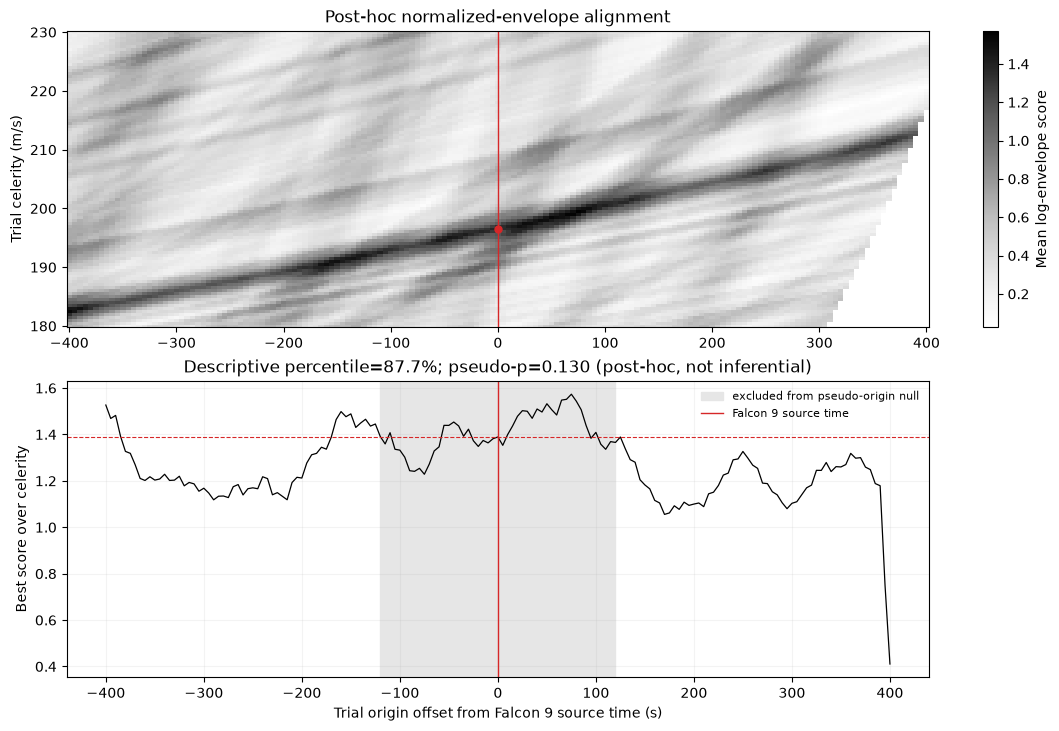

{
  "stations": [
    "IU.DWPF",
    "N4.257A",
    "N4.S54A"
  ],
  "known_source_best_celerity_mps": 196.5,
  "known_source_score": 1.3891263767776898,
  "descriptive_percentile": 87.71929824561403,
  "pseudo_p_posthoc_not_formal": 0.13043478260869565,
  "warning": "Stations and candidate peaks were selected after inspection; this is not a pre-registered or formal false-alarm test."
}


In [14]:
PSEUDO_ORIGIN_RANGE_S = 400.0
PSEUDO_ORIGIN_STEP_S = 5.0
PSEUDO_CELERITIES_MPS = np.arange(180.0, 230.01, 0.5)
PSEUDO_PACKET_HALF_WIDTH_S = 20.0
PSEUDO_NULL_EXCLUSION_S = 120.0


def normalized_envelope(trace: Trace) -> tuple[np.ndarray, np.ndarray]:
    data = np.asarray(trace.data, dtype=float)
    data = data - np.nanmedian(data)
    envelope = np.abs(hilbert(data))
    scale = robust_sigma(envelope)
    if not np.isfinite(scale) or scale <= 0:
        raise ValueError(f"Invalid envelope scale for {trace.id}")
    times = (
        float(trace.stats.starttime - SOURCE_TIME)
        + np.arange(trace.stats.npts) / float(trace.stats.sampling_rate)
    )
    z = np.maximum(0.0, (envelope - np.nanmedian(envelope)) / scale)
    return times, np.log1p(np.minimum(z, 100.0))


branch_envelopes = {}
for key in POSTHOC_SLOW_BRANCH:
    if key not in focused_waveforms:
        raise KeyError(f"Focused waveform was not loaded for {key[0]}.{key[1]}")
    trace = focused_waveforms[key]["filtered"]
    branch_envelopes[key] = normalized_envelope(trace)

branch_lookup = slow_branch.set_index(["network", "station"])
pseudo_offsets_s = np.arange(
    -PSEUDO_ORIGIN_RANGE_S,
    PSEUDO_ORIGIN_RANGE_S + PSEUDO_ORIGIN_STEP_S,
    PSEUDO_ORIGIN_STEP_S,
)
pseudo_scores = np.full(
    (len(PSEUDO_CELERITIES_MPS), len(pseudo_offsets_s)), np.nan
)

for ci, trial_celerity in enumerate(PSEUDO_CELERITIES_MPS):
    for oi, origin_offset in enumerate(pseudo_offsets_s):
        station_scores = []
        for key in POSTHOC_SLOW_BRANCH:
            distance_m = float(branch_lookup.loc[key, "distance_km"]) * 1000.0
            predicted = origin_offset + distance_m / trial_celerity
            time_s, envelope_score = branch_envelopes[key]
            mask = np.abs(time_s - predicted) <= PSEUDO_PACKET_HALF_WIDTH_S
            if mask.any():
                station_scores.append(float(np.nanmean(envelope_score[mask])))
        if len(station_scores) == len(POSTHOC_SLOW_BRANCH):
            pseudo_scores[ci, oi] = float(np.mean(station_scores))

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    best_score_by_offset = np.nanmax(pseudo_scores, axis=0)
known_index = int(np.argmin(np.abs(pseudo_offsets_s)))
known_score = float(best_score_by_offset[known_index])
known_best_celerity = float(
    PSEUDO_CELERITIES_MPS[np.nanargmax(pseudo_scores[:, known_index])]
)
null_mask = np.abs(pseudo_offsets_s) >= PSEUDO_NULL_EXCLUSION_S
null_scores = best_score_by_offset[null_mask]
null_scores = null_scores[np.isfinite(null_scores)]
if len(null_scores) < 20:
    raise RuntimeError(
        "Too few fully covered pseudo-origin trials; reduce "
        "PSEUDO_ORIGIN_RANGE_S or inspect waveform coverage"
    )
descriptive_percentile = 100.0 * float(np.mean(null_scores <= known_score))
pseudo_p = float((1 + np.sum(null_scores >= known_score)) / (1 + len(null_scores)))

fig, axes = plt.subplots(2, 1, figsize=(10.5, 7.2), constrained_layout=True)
mesh = axes[0].pcolormesh(
    pseudo_offsets_s, PSEUDO_CELERITIES_MPS, pseudo_scores,
    shading="auto", cmap="Greys",
)
axes[0].axvline(0, color="tab:red", lw=1.0)
axes[0].plot(0, known_best_celerity, "o", color="tab:red", ms=5)
axes[0].set(
    ylabel="Trial celerity (m/s)",
    title="Post-hoc normalized-envelope alignment",
)
fig.colorbar(mesh, ax=axes[0], label="Mean log-envelope score")

axes[1].plot(pseudo_offsets_s, best_score_by_offset, color="black", lw=0.9)
axes[1].axvspan(
    -PSEUDO_NULL_EXCLUSION_S, PSEUDO_NULL_EXCLUSION_S,
    color="0.9", label="excluded from pseudo-origin null",
)
axes[1].axvline(0, color="tab:red", lw=1.0, label="Falcon 9 source time")
axes[1].axhline(known_score, color="tab:red", ls="--", lw=0.8)
axes[1].set(
    xlabel="Trial origin offset from Falcon 9 source time (s)",
    ylabel="Best score over celerity",
    title=(f"Descriptive percentile={descriptive_percentile:.1f}%; "
           f"pseudo-p={pseudo_p:.3f} (post-hoc, not inferential)"),
)
axes[1].grid(True, alpha=0.15)
axes[1].legend(frameon=False, fontsize=8)

pseudo_pdf = OUTPUT_ROOT / "145_posthoc_pseudo_origin_alignment_test.pdf"
fig.savefig(pseudo_pdf, bbox_inches="tight")
plt.show()

pseudo_summary = {
    "stations": [f"{n}.{s}" for n, s in POSTHOC_SLOW_BRANCH],
    "known_source_best_celerity_mps": known_best_celerity,
    "known_source_score": known_score,
    "descriptive_percentile": descriptive_percentile,
    "pseudo_p_posthoc_not_formal": pseudo_p,
    "warning": (
        "Stations and candidate peaks were selected after inspection; this is "
        "not a pre-registered or formal false-alarm test."
    ),
}
(OUTPUT_ROOT / "145_posthoc_pseudo_origin_summary.json").write_text(
    json.dumps(pseudo_summary, indent=2) + "\n", encoding="utf-8"
)
print(json.dumps(pseudo_summary, indent=2))




## Northern-corridor source-reduced record section

This panel includes every screened infrasound station within 30 degrees of
north, not only the four highlighted candidates.  Coherent energy near zero
reduced time would provide a less selective check on the proposed slow
branch.  Each trace is normalized independently, so the panel tests timing
and morphology rather than amplitude decay.



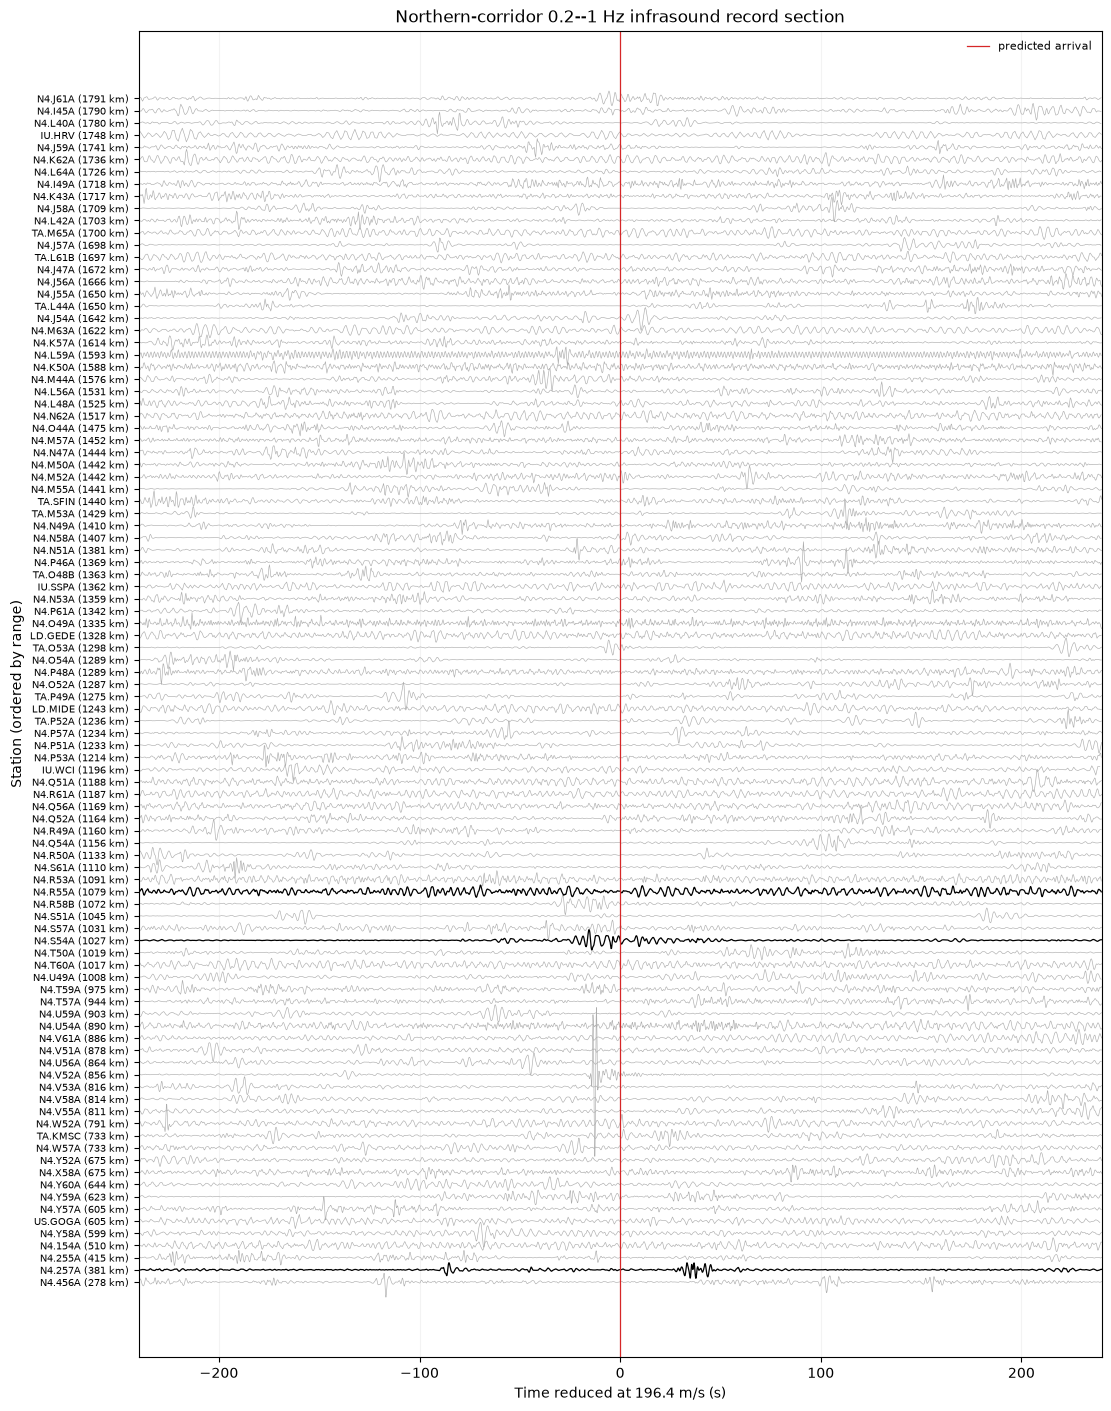

Northern-corridor records plotted: 98


In [15]:
CORRIDOR_AZIMUTH_HALF_WIDTH_DEG = 30.0
CORRIDOR_REDUCED_WINDOW_S = (-240.0, 240.0)


def angular_distance_deg(a: float, b: float) -> float:
    return abs((a - b + 180.0) % 360.0 - 180.0)


corridor_records = [
    record for record in diagnostic_records
    if record["sensor_type"] == "infrasound"
    and angular_distance_deg(float(record["azimuth_deg"]), 0.0)
    <= CORRIDOR_AZIMUTH_HALF_WIDTH_DEG
]
corridor_records.sort(key=lambda record: float(record["distance_km"]))

if not corridor_records:
    raise RuntimeError("No screened northern-corridor infrasound records")

fig_height = max(6.0, min(14.0, 0.25 * len(corridor_records) + 2.0))
fig, ax = plt.subplots(figsize=(11, fig_height), constrained_layout=True)

focused_keys = set(FOCUSED_REGIONAL_STATIONS)
yticks, ylabels = [], []
for row_index, record in enumerate(corridor_records):
    time_s = np.asarray(record["time_s"], dtype=float)
    data = np.asarray(record["data"], dtype=float)
    reduced_time = (
        time_s - float(record["distance_km"]) * 1000.0 / fixed_celerity_mps
    )
    mask = (
        (reduced_time >= CORRIDOR_REDUCED_WINDOW_S[0])
        & (reduced_time <= CORRIDOR_REDUCED_WINDOW_S[1])
        & np.isfinite(data)
    )
    if not mask.any():
        continue
    scale = np.nanpercentile(np.abs(data[mask]), 99.0)
    if not np.isfinite(scale) or scale <= 0:
        continue
    key = (str(record["network"]), str(record["station"]))
    color = "black" if key in focused_keys else "0.68"
    linewidth = 0.9 if key in focused_keys else 0.45
    ax.plot(
        reduced_time[mask], row_index + 0.42 * data[mask] / scale,
        color=color, lw=linewidth,
    )
    yticks.append(row_index)
    ylabels.append(
        f"{record['network']}.{record['station']} "
        f"({float(record['distance_km']):.0f} km)"
    )

ax.axvline(0, color="tab:red", lw=0.9, label="predicted arrival")
ax.set(
    xlim=CORRIDOR_REDUCED_WINDOW_S,
    xlabel=f"Time reduced at {fixed_celerity_mps:.1f} m/s (s)",
    ylabel="Station (ordered by range)",
    title="Northern-corridor 0.2--1 Hz infrasound record section",
)
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels, fontsize=7)
ax.grid(True, axis="x", alpha=0.15)
ax.legend(frameon=False, fontsize=8)

corridor_pdf = OUTPUT_ROOT / "145_northern_corridor_source_reduced_section.pdf"
fig.savefig(corridor_pdf, bbox_inches="tight")
plt.show()
print(f"Northern-corridor records plotted: {len(yticks)}")




## BCHH comparison in the regional 0.2--1 Hz band

BCHH should be inspected in the same band because it establishes whether the
local source sequence radiated energy in the band observed regionally.
However, the upper-stage, principal, payload-impact, payload-explosion, and
event-024 signals are separated by only a few to approximately 11 seconds.
At 0.2--1 Hz they overlap strongly, so this plot characterizes the Phase-I
source sequence and cannot yield an isolated principal-explosion period.



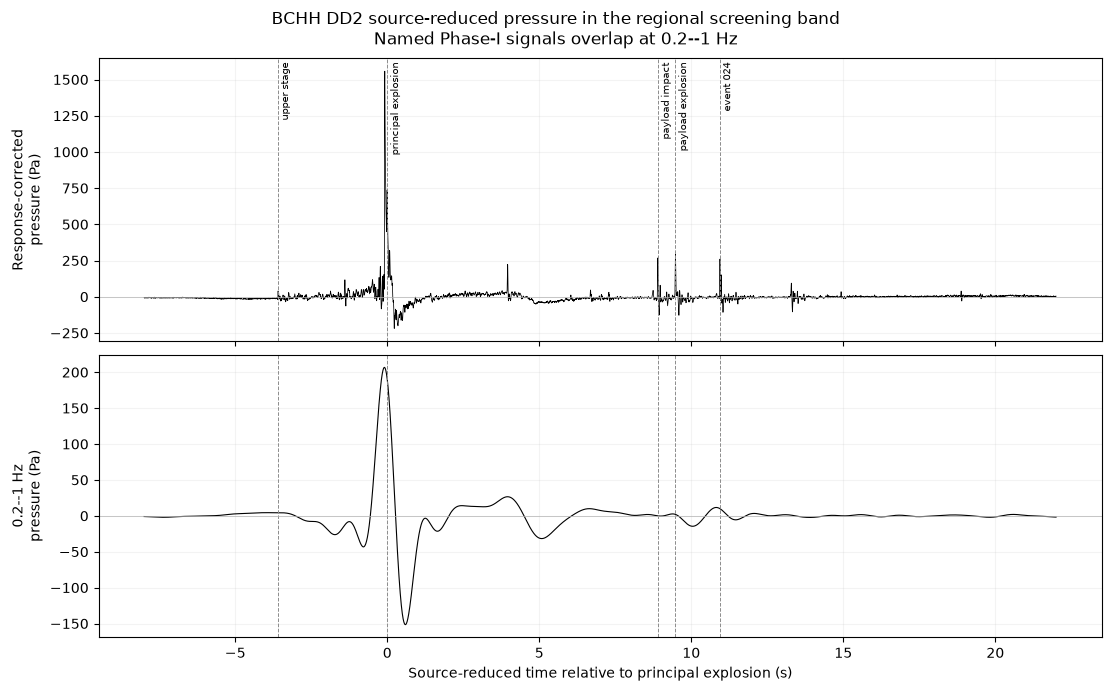

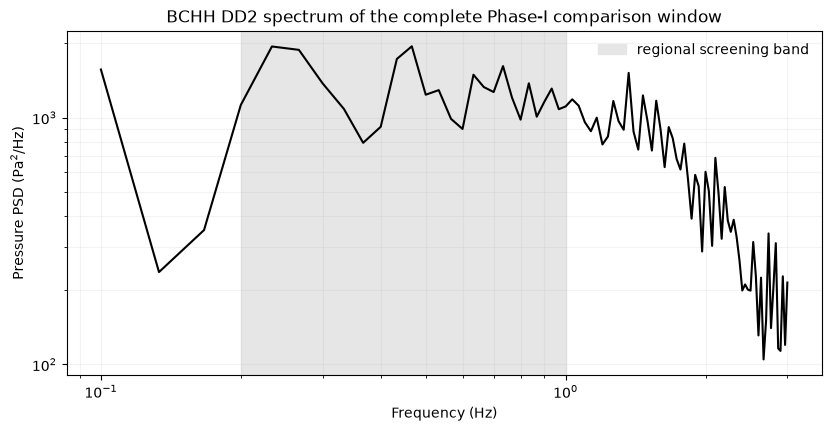

In [16]:
BCHH_DD2_DISTANCE_M = 1408.34
BCHH_SOURCE_REDUCTION_SPEED_MPS = 351.0
BCHH_TRAVEL_TIME_S = BCHH_DD2_DISTANCE_M / BCHH_SOURCE_REDUCTION_SPEED_MPS

if config.FINAL_CORRECTED_MSEED.exists():
    bchh_stream = read(str(config.FINAL_CORRECTED_MSEED))
elif config.FINAL_CORRECTED_PICKLE.exists():
    bchh_stream = pd.read_pickle(config.FINAL_CORRECTED_PICKLE)
else:
    raise FileNotFoundError(
        "Run Notebook 000 first; no response-corrected BCHH product was found"
    )

bchh_dd2_matches = bchh_stream.select(channel="DD2")
if not bchh_dd2_matches:
    bchh_dd2_matches = bchh_stream.select(id="*.*.*.DD2")
if len(bchh_dd2_matches) != 1:
    raise RuntimeError(f"Expected one BCHH DD2 trace, found {len(bchh_dd2_matches)}")

bchh_dd2 = bchh_dd2_matches[0].copy()
bchh_dd2.detrend("demean")
bchh_dd2_02_1, bchh_effective_band = filtered_trace(
    bchh_dd2, ACOUSTIC_BAND_HZ
)

# Express receiver time as source-reduced time relative to the principal event.
bchh_plot_start_reduced_s = -8.0
bchh_plot_end_reduced_s = 22.0
bchh_receiver_reference = SOURCE_TIME + BCHH_TRAVEL_TIME_S
bchh_start = bchh_receiver_reference + bchh_plot_start_reduced_s
bchh_end = bchh_receiver_reference + bchh_plot_end_reduced_s

bchh_raw_window = bchh_dd2.slice(bchh_start, bchh_end, nearest_sample=False)
bchh_band_window = bchh_dd2_02_1.slice(
    bchh_start, bchh_end, nearest_sample=False
)

def bchh_reduced_times(trace: Trace) -> np.ndarray:
    return (
        float(trace.stats.starttime - bchh_receiver_reference)
        + np.arange(trace.stats.npts) / float(trace.stats.sampling_rate)
    )

named_offsets = {
    key: float(UTCDateTime(value) - SOURCE_TIME)
    for key, value in config.SOURCE_EVENT_TIMES.items()
}
named_display = {
    "upper_stage": "upper stage",
    "lower_stage": "principal explosion",
    "payload_impact": "payload impact",
    "payload_explosion": "payload explosion",
    "event_024": "event 024",
}

fig, axes = plt.subplots(2, 1, figsize=(11, 6.8), sharex=True, constrained_layout=True)
axes[0].plot(
    bchh_reduced_times(bchh_raw_window), bchh_raw_window.data,
    color="black", lw=0.55,
)
axes[1].plot(
    bchh_reduced_times(bchh_band_window), bchh_band_window.data,
    color="black", lw=0.8,
)
for ax in axes:
    for key, offset in named_offsets.items():
        if bchh_plot_start_reduced_s <= offset <= bchh_plot_end_reduced_s:
            ax.axvline(offset, color="0.55", lw=0.7, ls="--")
    ax.axhline(0, color="0.7", lw=0.5)
    ax.grid(True, alpha=0.15)
axes[0].set_ylabel("Response-corrected\npressure (Pa)")
axes[1].set_ylabel("0.2--1 Hz\npressure (Pa)")
axes[1].set_xlabel("Source-reduced time relative to principal explosion (s)")
for key, offset in named_offsets.items():
    if bchh_plot_start_reduced_s <= offset <= bchh_plot_end_reduced_s:
        axes[0].annotate(
            named_display.get(key, key), (offset, axes[0].get_ylim()[1]),
            xytext=(2, -3), textcoords="offset points", rotation=90,
            ha="left", va="top", fontsize=7,
        )
fig.suptitle(
    "BCHH DD2 source-reduced pressure in the regional screening band\n"
    "Named Phase-I signals overlap at 0.2--1 Hz"
)

bchh_pdf = OUTPUT_ROOT / "145_bchh_dd2_regional_band_comparison.pdf"
fig.savefig(bchh_pdf, bbox_inches="tight")
plt.show()

# A spectrum of the complete displayed sequence is useful for comparing its
# broad source band with the regional waveforms, but is not an event period.
phase_data = np.asarray(bchh_raw_window.data, dtype=float)
phase_data = phase_data - np.nanmean(phase_data)
frequency_hz, psd = periodogram(
    phase_data,
    fs=float(bchh_raw_window.stats.sampling_rate),
    detrend="linear", scaling="density",
)
frequency_mask = (frequency_hz >= 0.1) & (frequency_hz <= 3.0)
fig, ax = plt.subplots(figsize=(8.2, 4.2), constrained_layout=True)
ax.loglog(frequency_hz[frequency_mask], psd[frequency_mask], color="black")
ax.axvspan(0.2, 1.0, color="0.9", label="regional screening band")
ax.set(
    xlabel="Frequency (Hz)", ylabel="Pressure PSD (Pa$^2$/Hz)",
    title="BCHH DD2 spectrum of the complete Phase-I comparison window",
)
ax.grid(True, which="both", alpha=0.15)
ax.legend(frameon=False)
bchh_spectrum_pdf = OUTPUT_ROOT / "145_bchh_dd2_regional_band_spectrum.pdf"
fig.savefig(bchh_spectrum_pdf, bbox_inches="tight")
plt.show()




## Amplitude, dominant-period, and guarded yield worksheet

Silber and Scamfer (2026) estimated New Glenn yield from the dominant period
of accepted primary tropospheric and stratospheric arrivals.  They did not
infer yield from pressure amplitude, and they excluded thermospheric arrivals
because propagation preferentially removes high frequencies.  The same guard
is imposed here: slow/thermospheric Falcon 9 candidates receive no yield.



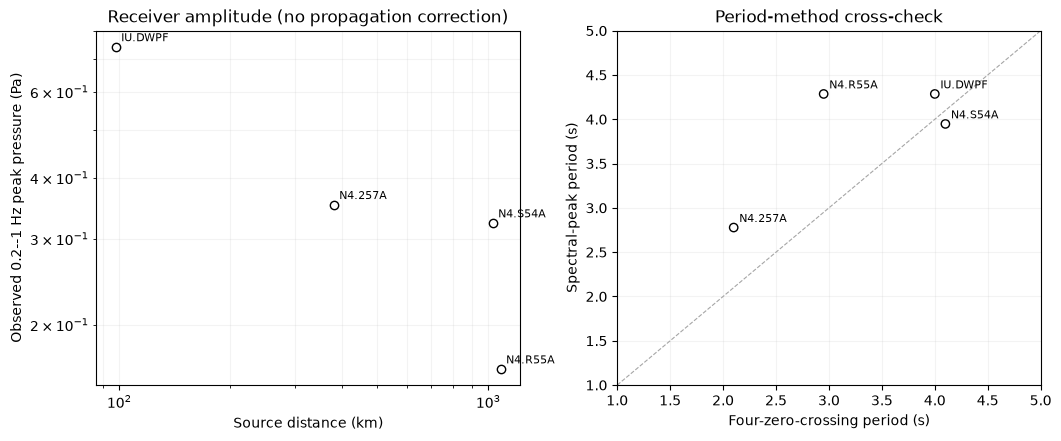

IMPORTANT: pressure amplitude is reported at the receiver. The p*r and p*sqrt(r) columns are geometric-spreading diagnostics, not source pressures or yield estimates; atmospheric attenuation and focusing have not been corrected.
No period-derived yield should be reported unless manually accepted tropospheric/stratospheric arrivals are identified and their four-zero-crossing periods agree with spectral peaks.


,network,station,channel,distance_km,azimuth_deg,phase,arrival_time_utc,apparent_celerity_mps,filtered_peak_abs_pressure_pa,spherical_reduced_amplitude_pa_km,cylindrical_reduced_amplitude_pa_sqrt_km,zero_crossing_period_s,spectral_peak_period_s,period_agreement_fraction,yield_eligible_primary_arrival,revelle_period_yield_kt,yield_exclusion_reason
0,IU,DWPF,LDO,97.682827,239.380046,thermospheric_or_slow,2016-09-01T13:15:42.216782,192.781160,0.741628,72.444303,7.329851,4.00,4.285714,0.071429,False,NaN,slow/thermospheric candidate; period-yield rel...
1,N4,257A,BDF,380.774690,353.598564,thermospheric_or_slow,2016-09-01T13:40:11.331640,192.717489,0.352337,134.160841,6.875301,2.10,2.777778,0.322751,False,NaN,slow/thermospheric candidate; period-yield rel...
2,N4,S54A,BDF,1026.822519,356.373966,thermospheric_or_slow,2016-09-01T14:34:08.105979,196.988839,0.323173,331.841237,10.355776,4.10,3.947368,0.037227,False,NaN,slow/thermospheric candidate; period-yield rel...
3,N4,R55A,BDF,1078.973087,2.137245,thermospheric_or_slow,2016-09-01T14:27:18.360087,224.652837,0.162293,175.109594,5.330950,2.95,4.285714,0.452785,False,NaN,slow/thermospheric candidate; period-yield rel...


2749

In [17]:
MANUAL_PACKET_HALF_WIDTH_S = {
    ("IU", "DWPF"): 60.0,
    ("N4", "257A"): 75.0,
    ("N4", "S54A"): 75.0,
    ("N4", "R55A"): 75.0,
}
YIELD_ELIGIBLE_PHASES = {"tropospheric", "stratospheric"}


def zero_crossing_period_s(trace: Trace, center: UTCDateTime, half_width_s: float) -> float:
    packet = trace.slice(
        center - half_width_s, center + half_width_s, nearest_sample=False
    )
    data = np.asarray(packet.data, dtype=float)
    data = data - np.nanmean(data)
    if data.size < 8:
        return np.nan
    envelope_peak = int(np.nanargmax(np.abs(hilbert(data))))
    crossings = np.flatnonzero(np.signbit(data[:-1]) != np.signbit(data[1:]))
    before = crossings[crossings < envelope_peak]
    after = crossings[crossings >= envelope_peak]
    if len(before) < 2 or len(after) < 2:
        return np.nan
    chosen = np.r_[before[-2:], after[:2]]
    crossing_times = chosen / float(packet.stats.sampling_rate)
    # Adjacent zero crossings are approximately one half-period apart.
    return float(2.0 * np.median(np.diff(crossing_times)))


def spectral_peak_period_s(trace: Trace, center: UTCDateTime, half_width_s: float) -> float:
    packet = trace.slice(
        center - half_width_s, center + half_width_s, nearest_sample=False
    )
    data = np.asarray(packet.data, dtype=float)
    data = data - np.nanmean(data)
    frequencies, power = periodogram(
        data, fs=float(packet.stats.sampling_rate), detrend="linear"
    )
    mask = (frequencies >= 0.2) & (frequencies <= 1.0) & np.isfinite(power)
    if not mask.any():
        return np.nan
    peak_frequency = float(frequencies[mask][np.nanargmax(power[mask])])
    return 1.0 / peak_frequency if peak_frequency > 0 else np.nan


def revelle_1997_period_yield_kt(period_s: float) -> float:
    """Low-yield relation used by Silber and Scamfer (2026)."""
    if not np.isfinite(period_s) or period_s <= 0:
        return np.nan
    return float(10.0 ** (3.34 * np.log10(period_s) - 2.28))


far_field_rows = []
for candidate in focused_candidate_metrics.itertuples(index=False):
    key = (str(candidate.network), str(candidate.station))
    if key not in focused_waveforms:
        continue
    filtered = focused_waveforms[key]["filtered"]
    center = UTCDateTime(candidate.peak_time_utc)
    half_width = MANUAL_PACKET_HALF_WIDTH_S[key]
    packet = filtered.slice(
        center - half_width, center + half_width, nearest_sample=False
    )
    peak_abs_pa = float(np.nanmax(np.abs(packet.data)))
    zero_period = zero_crossing_period_s(filtered, center, half_width)
    spectral_period = spectral_peak_period_s(filtered, center, half_width)
    phase = str(candidate.phase)
    eligible = phase in YIELD_ELIGIBLE_PHASES
    # Deliberately NaN for all currently selected slow/thermospheric candidates.
    yield_kt = revelle_1997_period_yield_kt(zero_period) if eligible else np.nan
    far_field_rows.append({
        "network": key[0],
        "station": key[1],
        "channel": str(candidate.channel),
        "distance_km": float(candidate.distance_km),
        "azimuth_deg": float(candidate.source_to_station_azimuth_deg),
        "phase": phase,
        "arrival_time_utc": str(candidate.peak_time_utc),
        "apparent_celerity_mps": float(candidate.apparent_speed_mps),
        "filtered_peak_abs_pressure_pa": peak_abs_pa,
        "spherical_reduced_amplitude_pa_km": (
            peak_abs_pa * float(candidate.distance_km)
        ),
        "cylindrical_reduced_amplitude_pa_sqrt_km": (
            peak_abs_pa * np.sqrt(float(candidate.distance_km))
        ),
        "zero_crossing_period_s": zero_period,
        "spectral_peak_period_s": spectral_period,
        "period_agreement_fraction": (
            abs(zero_period - spectral_period) / zero_period
            if np.isfinite(zero_period) and zero_period > 0
            else np.nan
        ),
        "yield_eligible_primary_arrival": eligible,
        "revelle_period_yield_kt": yield_kt,
        "yield_exclusion_reason": (
            "" if eligible else
            "slow/thermospheric candidate; period-yield relation not calibrated"
        ),
    })

far_field_measurements = pd.DataFrame(far_field_rows)
far_field_measurements.to_csv(
    OUTPUT_ROOT / "145_regional_candidate_amplitude_period_yield_guard.csv",
    index=False,
)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3), constrained_layout=True)
axes[0].loglog(
    far_field_measurements["distance_km"],
    far_field_measurements["filtered_peak_abs_pressure_pa"],
    "o", mfc="none", mec="black",
)
for row in far_field_measurements.itertuples(index=False):
    axes[0].annotate(
        f"{row.network}.{row.station}",
        (row.distance_km, row.filtered_peak_abs_pressure_pa),
        xytext=(4, 4), textcoords="offset points", fontsize=8,
    )
axes[0].set(
    xlabel="Source distance (km)",
    ylabel="Observed 0.2--1 Hz peak pressure (Pa)",
    title="Receiver amplitude (no propagation correction)",
)
axes[0].grid(True, which="both", alpha=0.15)

valid_period = (
    far_field_measurements["zero_crossing_period_s"].notna()
    & far_field_measurements["spectral_peak_period_s"].notna()
)
period_subset = far_field_measurements.loc[valid_period]
axes[1].plot([1.0, 5.0], [1.0, 5.0], color="0.65", lw=0.8, ls="--")
axes[1].scatter(
    period_subset["zero_crossing_period_s"],
    period_subset["spectral_peak_period_s"],
    facecolors="none", edgecolors="black",
)
for row in period_subset.itertuples(index=False):
    axes[1].annotate(
        f"{row.network}.{row.station}",
        (row.zero_crossing_period_s, row.spectral_peak_period_s),
        xytext=(4, 4), textcoords="offset points", fontsize=8,
    )
axes[1].set(
    xlabel="Four-zero-crossing period (s)",
    ylabel="Spectral-peak period (s)",
    title="Period-method cross-check",
    xlim=(1.0, 5.0), ylim=(1.0, 5.0),
)
axes[1].grid(True, alpha=0.15)

amplitude_period_pdf = (
    OUTPUT_ROOT / "145_regional_candidate_amplitude_period_diagnostics.pdf"
)
fig.savefig(amplitude_period_pdf, bbox_inches="tight")
plt.show()

print(
    "IMPORTANT: pressure amplitude is reported at the receiver. The p*r and "
    "p*sqrt(r) columns are geometric-spreading diagnostics, not source "
    "pressures or yield estimates; atmospheric attenuation and focusing have "
    "not been corrected."
)
print(
    "No period-derived yield should be reported unless manually accepted "
    "tropospheric/stratospheric arrivals are identified and their four-zero-"
    "crossing periods agree with spectral peaks."
)
display(far_field_measurements)

# Extend the existing run metadata without removing the original screening
# provenance.
metadata_path = OUTPUT_ROOT / "regional_detectability_run_metadata.json"
if metadata_path.exists():
    extended_metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
else:
    extended_metadata = {}
extended_metadata["focused_regional_validation"] = {
    "stations": [f"{n}.{s}" for n, s in FOCUSED_REGIONAL_STATIONS],
    "posthoc_slow_branch": [f"{n}.{s}" for n, s in POSTHOC_SLOW_BRANCH],
    "fixed_origin_celerity_mps": fixed_celerity_mps,
    "free_origin_celerity_mps": free_celerity_mps,
    "free_origin_offset_s": float(free_origin_offset_s),
    "pseudo_origin_test_warning": pseudo_summary["warning"],
    "bchh_comparison_band_hz": list(ACOUSTIC_BAND_HZ),
    "yield_method": (
        "ReVelle (1997) period-yield relation as used by Silber and Scamfer "
        "(2026), restricted to manually accepted primary tropospheric or "
        "stratospheric arrivals"
    ),
    "current_yield_status": (
        "No selected slow/thermospheric candidate is eligible for yield estimation"
    ),
}
metadata_path.write_text(
    json.dumps(extended_metadata, indent=2) + "\n", encoding="utf-8"
)
